In [1]:
# numpy and pandas for data manipulation
import numpy as np
import pandas as pd 

# File system manangement
import os


# ------------------- IMPORT SRC ------------------------------------
# src is the parent folder of notebooks, so we need to add it to sys.path to import config and utils
import sys
notebook_dir = os.getcwd() 

# Parent folder of src
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
sys.path.append(project_root)

print("sys.path contains:", sys.path[-1])

from src.config import Config as Config  
from src.data_loader import load_data, prepare_data

cfg = Config

KAGGLE_EVAL = cfg.KAGGLE_EVAL
RANDOM_STATE = cfg.RANDOM_STATE
TASK = cfg.TASK
USE_POSTPROCESSING = cfg.USE_POSTPROCESSING
TARGET = cfg.TARGET

# -------------------------------------------------------


from sklearn.model_selection import train_test_split

# Suppress warnings 
import warnings
warnings.filterwarnings('ignore')


# matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearnex import patch_sklearn
patch_sklearn()  # patches scikit-learn algorithms
# from sklearnex import unpatch_sklearn
# unpatch_sklearn()



sys.path contains: /home/ismail


Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:


X_train, X_test, y_train, y_test = load_data("prep", data_dir='./data/')




# Prepare
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True # ,label_map = {"A": 1, "B": 0, "C": 2}
)

cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()


Number of classes: 2
X_train shape: (80024, 170)
X_test shape: (34297, 170)
y_train shape: (80024,)
y_test shape: (34297,)


In [ ]:
###

##### Setup

In [ ]:
"""
Q3 — Dimensionality Reduction Analysis
========================================
All methods tested in one place. Run each function independently,
read the output, then write your report choosing the best method.

Methods covered
---------------
1.  PCA            — linear, fast, interpretable, variance-based
2.  Kernel PCA     — non-linear PCA (RBF, poly kernels)
3.  Incremental PCA — PCA for large datasets that don't fit in RAM
4.  Sparse PCA     — PCA with sparsity constraint (interpretable loadings)
5.  Factor Analysis — probabilistic generative model behind the data
6.  Truncated SVD  — works on sparse matrices, no centering needed
7.  t-SNE          — non-linear 2-D / 3-D visualisation
8.  UMAP           — faster than t-SNE, preserves global structure better
9.  LLE            — Locally Linear Embedding, manifold learning
10. Isomap         — geodesic distance manifold learning
11. MDS            — Multi-Dimensional Scaling (metric & non-metric)
12. NMF            — Non-negative Matrix Factorisation (parts-based)
13. Autoencoder    — neural network dimensionality reduction

Usage
-----
    from dimensionality_reduction import (
        run_pca_full,
        run_nonlinear_2d,
        run_all_methods_comparison,
        how_many_dimensions,
        run_autoencoder,
    )

    # Recommended order:
    # 1. how_many_dimensions  → find the right n_components
    # 2. run_pca_full         → understand linear structure
    # 3. run_nonlinear_2d     → visualise non-linear clusters
    # 4. run_all_methods_comparison → compare all methods
    # 5. run_autoencoder      → if non-linear reduction needed
"""

In [4]:


from __future__ import annotations
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

from sklearn.preprocessing      import StandardScaler, RobustScaler
from sklearn.decomposition      import (PCA, KernelPCA, SparsePCA,
                                        FactorAnalysis, TruncatedSVD,
                                        NMF, IncrementalPCA)
from sklearn.manifold           import TSNE, LocallyLinearEmbedding, Isomap, MDS
from sklearn.metrics            import silhouette_score
from scipy.stats                import pearsonr

warnings.filterwarnings("ignore")

_C0, _C1 = "#4C72B0", "#DD8452"

plt.rcParams.update({
    "figure.dpi":      130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.color":      "#E8E8E8",
    "grid.linewidth":  0.5,
})





# HELPERS

def _scale(X: pd.DataFrame, method: str = "standard") -> np.ndarray:
    """method: 'standard' | 'robust'"""
    num_cols = X.select_dtypes(include=np.number).columns
    Xn = X[num_cols].fillna(X[num_cols].median())
    scaler = StandardScaler() if method == "standard" else RobustScaler()
    return scaler.fit_transform(Xn), num_cols.tolist()


def _save(fig, save_path: str | None, name: str):
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        fig.savefig(os.path.join(save_path, name),
                    bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


def _scatter2d(ax, Z: np.ndarray, y: np.ndarray | None,
               title: str, xlabel: str = "Dim 1", ylabel: str = "Dim 2"):
    """coloured by class if y is provided."""
    if y is not None:
        colors = np.where(np.asarray(y) == 1, _C1, _C0)
        ax.scatter(Z[:, 0], Z[:, 1], c=colors, alpha=0.35, s=8, linewidths=0)
        from matplotlib.patches import Patch
        ax.legend(handles=[Patch(facecolor=_C0, label="Class 0"),
                            Patch(facecolor=_C1, label="Class 1")],
                  fontsize=7, loc="best")
    else:
        ax.scatter(Z[:, 0], Z[:, 1], alpha=0.35, s=8, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel(ylabel, fontsize=8)

#### HOW MANY DIMENSIONS?

In [ ]:
def how_many_dimensions(
    X:          pd.DataFrame,
    y:          pd.Series | np.ndarray | None = None,
    targets:    list[float] = [0.80, 0.90, 0.95, 0.99],
    save_path:  str | None = None,
) -> pd.DataFrame:
    """
    Question: "how many dimensions capture X% of variance?"

    Plots
    -----
    1. Scree plot (individual explained variance per component)
    2. Cumulative explained variance with target lines
    3. Kaiser criterion (eigenvalues > 1)
    4. Reconstruction error vs n_components

    Returns
    -------
    DataFrame with n_components and cumulative variance for each target.
    """
    Xs, _ = _scale(X)
    pca   = PCA(random_state=42).fit(Xs)

    ev    = pca.explained_variance_ratio_
    cum   = np.cumsum(ev)
    evals = pca.explained_variance_          # eigenvalues
    n_kaiser = int((evals > 1).sum())

    # ── Reconstruction error vs n_components ────────────────────────────
    steps  = np.unique(np.linspace(1, min(len(ev), 150), 30).astype(int))
    recon  = []
    for k in steps:
        p = PCA(n_components=k, random_state=42)
        Xr = p.inverse_transform(p.fit_transform(Xs))
        recon.append(np.mean((Xs - Xr) ** 2))

    # ── Plots ────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 10))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
    fig.suptitle("How Many Dimensions Are Needed?",
                 fontsize=14, fontweight="bold")

    # Plot 1: scree
    ax0 = fig.add_subplot(gs[0, 0])
    ax0.bar(range(1, min(51, len(ev)+1)), ev[:50],
            color="#4C72B0", alpha=0.75)
    ax0.set_title("Scree Plot\n(individual variance per component)")
    ax0.set_xlabel("Component")
    ax0.set_ylabel("Explained variance ratio")

    # Plot 2: cumulative
    ax1 = fig.add_subplot(gs[0, 1])
    ax1.plot(range(1, len(cum)+1), cum, color="#4C72B0", linewidth=2)
    colors_t = ["#e6194b", "#f58231", "#3cb44b", "#4363d8"]
    for t, col in zip(targets, colors_t):
        n_t = int(np.argmax(cum >= t)) + 1
        ax1.axhline(t, color=col, linestyle="--", alpha=0.7,
                    label=f"{t:.0%} → {n_t} components")
        ax1.axvline(n_t, color=col, linestyle=":", alpha=0.5)
    ax1.set_title("Cumulative Explained Variance")
    ax1.set_xlabel("Number of components")
    ax1.set_ylabel("Cumulative variance")
    ax1.legend(fontsize=7)
    ax1.set_ylim(0, 1.02)

    # Plot 3: eigenvalues (Kaiser)
    ax2 = fig.add_subplot(gs[0, 2])
    top_k = min(50, len(evals))
    ax2.bar(range(1, top_k+1), evals[:top_k],
            color=np.where(evals[:top_k] > 1, "#3cb44b", "#aaaaaa"),
            alpha=0.8)
    ax2.axhline(1.0, color="red", linestyle="--", linewidth=1.2,
                label=f"Kaiser criterion: {n_kaiser} components")
    ax2.set_title("Eigenvalues (Kaiser Criterion)")
    ax2.set_xlabel("Component")
    ax2.set_ylabel("Eigenvalue")
    ax2.legend(fontsize=8)

    # Plot 4: reconstruction error
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(steps, recon, "o-", color="#DD8452", linewidth=2, markersize=4)
    ax3.set_title("Reconstruction MSE vs n_components")
    ax3.set_xlabel("n_components")
    ax3.set_ylabel("Mean squared reconstruction error")

    # Plot 5: PCA 2-D coloured by y
    ax4 = fig.add_subplot(gs[1, 1])
    pca2 = PCA(n_components=2, random_state=42)
    Z2   = pca2.fit_transform(Xs)
    _scatter2d(ax4, Z2, y,
               f"PCA 2D\n({sum(pca2.explained_variance_ratio_):.1%} variance)",
               "PC1", "PC2")

    # Plot 6: PCA 3-D
    ax5 = fig.add_subplot(gs[1, 2], projection="3d")
    pca3 = PCA(n_components=3, random_state=42)
    Z3   = pca3.fit_transform(Xs)
    c3   = np.where(np.asarray(y) == 1, _C1, _C0) if y is not None else "#4C72B0"
    ax5.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], c=c3, alpha=0.25, s=5)
    ax5.set_title("PCA 3D", fontsize=9)
    ax5.set_xlabel("PC1", fontsize=7)
    ax5.set_ylabel("PC2", fontsize=7)
    ax5.set_zlabel("PC3", fontsize=7)

    _save(fig, save_path, "DR_01_how_many_dims.png")

    # ── Summary table ────────────────────────────────────────────────────
    rows = []
    for t in targets:
        n_t = int(np.argmax(cum >= t)) + 1
        rows.append({"variance_target": f"{t:.0%}",
                     "n_components": n_t,
                     "compression_ratio": round(n_t / Xs.shape[1], 3)})
    rows.append({"variance_target": "Kaiser (eig>1)",
                 "n_components": n_kaiser,
                 "compression_ratio": round(n_kaiser / Xs.shape[1], 3)})

    summary = pd.DataFrame(rows)
    print(f"\n{'═'*50}")
    print("  Dimensionality Summary")
    print(f"{'═'*50}")
    print(f"  Original dimensions : {Xs.shape[1]}")
    print(f"  Samples             : {Xs.shape[0]:,}")
    print(f"\n{summary.to_string(index=False)}")
    print(f"{'═'*50}")

    return summary

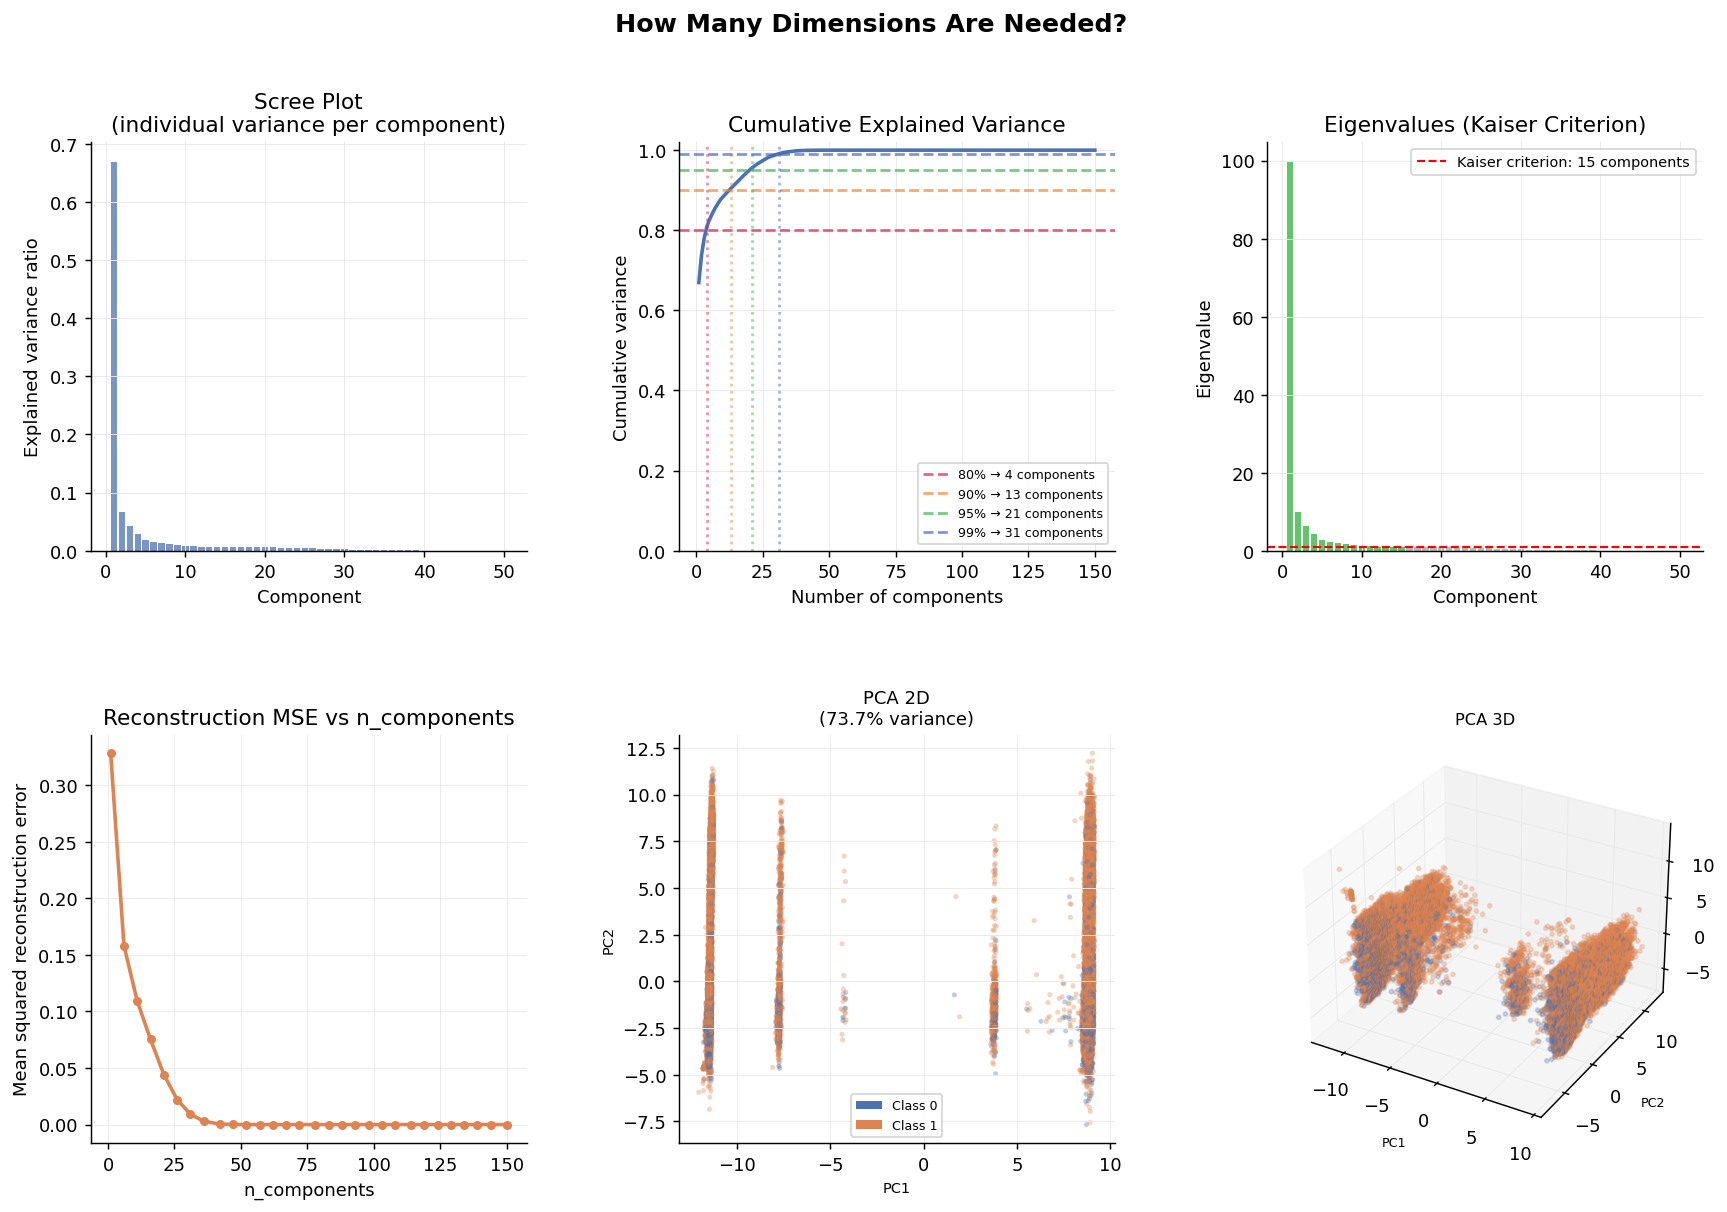


══════════════════════════════════════════════════
  Dimensionality Summary
══════════════════════════════════════════════════
  Original dimensions : 150
  Samples             : 80,024

variance_target  n_components  compression_ratio
            80%             4              0.027
            90%            13              0.087
            95%            21              0.140
            99%            31              0.207
 Kaiser (eig>1)            15              0.100
══════════════════════════════════════════════════


In [7]:
summary = how_many_dimensions(X_train, y_train_numeric)


**PCA(RobustScaler)**

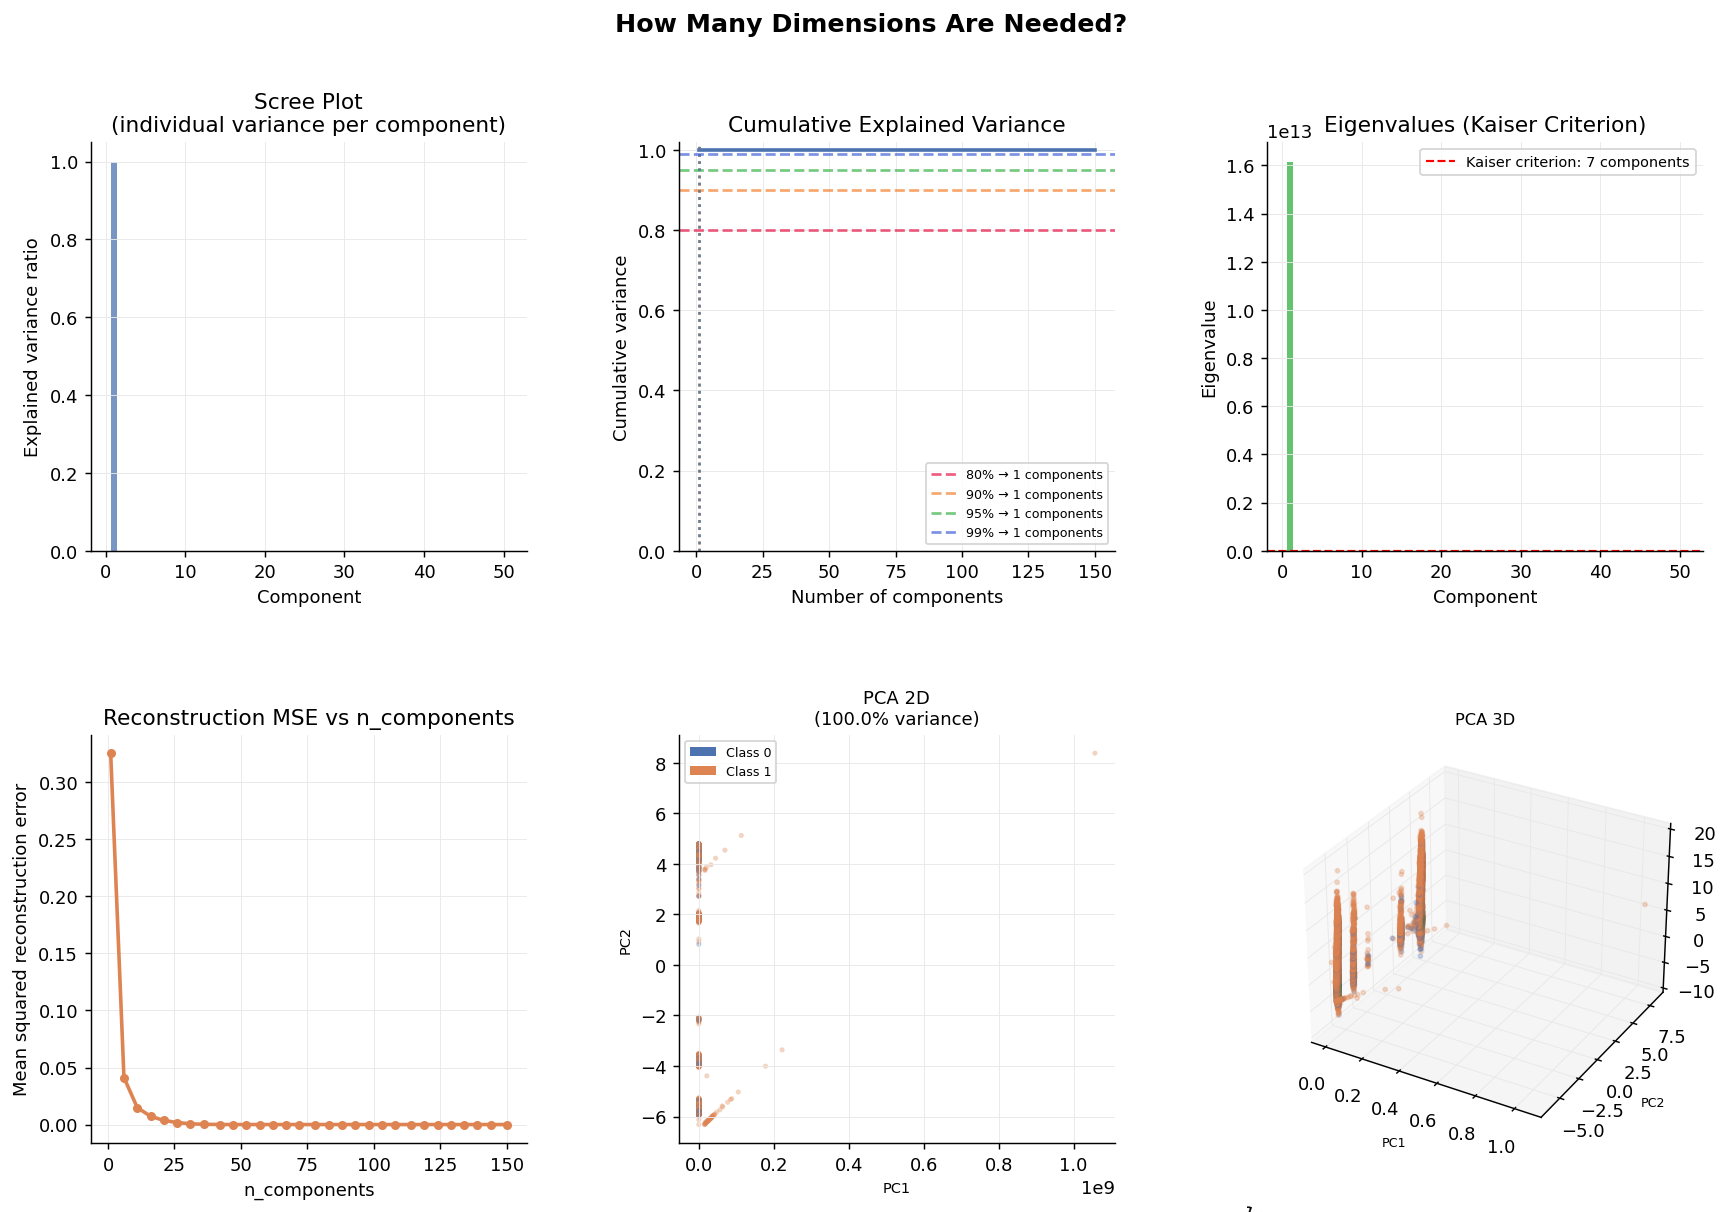


══════════════════════════════════════════════════
  Dimensionality Summary
══════════════════════════════════════════════════
  Original dimensions : 150
  Samples             : 80,024

variance_target  n_components  compression_ratio
            80%             1              0.007
            90%             1              0.007
            95%             1              0.007
            99%             1              0.007
 Kaiser (eig>1)             7              0.047
══════════════════════════════════════════════════


In [9]:
summary = how_many_dimensions(X_train, y_train_numeric)


#### PCA Analysis

In [13]:

# ─────────────────────────────────────────────────────────────────────────────
# 2.  PCA — FULL ANALYSIS
# ─────────────────────────────────────────────────────────────────────────────
def run_pca_full(
    X:           pd.DataFrame,
    y:           pd.Series | np.ndarray | None = None,
    n_components: int  = 30,
    save_path:   str | None = None,
) -> dict:
    """
    Full PCA analysis:
    - Loadings heatmap (which original features drive each PC)
    - Biplot (PC1 vs PC2 with feature arrows)
    - Per-component class separation (t-test statistic)
    - Correlation of each PC with the target
    - Explained variance by component group

    Returns
    -------
    dict with {pca, Z, loadings_df, pc_target_corr}
    """
    Xs, feat_names = _scale(X)
    n_components   = min(n_components, Xs.shape[1], Xs.shape[0] - 1)

    pca = PCA(n_components=n_components, random_state=42)
    Z   = pca.fit_transform(Xs)
    ev  = pca.explained_variance_ratio_

    # ── Loadings DataFrame ────────────────────────────────────────────────
    loadings_df = pd.DataFrame(
        pca.components_.T,
        index   = feat_names,
        columns = [f"PC{i+1}" for i in range(n_components)],
    )

    # ── PC vs target correlation ──────────────────────────────────────────
    pc_target_corr = None
    if y is not None:
        y_arr = np.asarray(y)
        corrs = [pearsonr(Z[:, i], y_arr)[0] for i in range(n_components)]
        pc_target_corr = pd.Series(corrs,
                                   index=[f"PC{i+1}" for i in range(n_components)],
                                   name="corr_with_target")

    # ── Figure 1: Scree + Cumulative ──────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("PCA Analysis", fontsize=13, fontweight="bold")

    axes[0].bar(range(1, n_components+1), ev, color=_C0, alpha=0.8)
    axes[0].set_title("Explained variance per PC")
    axes[0].set_xlabel("PC")
    axes[0].set_ylabel("Variance ratio")

    axes[1].plot(range(1, n_components+1), np.cumsum(ev), "o-", color=_C0,
                 linewidth=2, markersize=3)
    for tgt, col in [(0.80, "green"), (0.90, "orange"), (0.95, "red")]:
        n_t = int(np.argmax(np.cumsum(ev) >= tgt)) + 1
        axes[1].axhline(tgt, linestyle="--", color=col, alpha=0.6,
                        label=f"{tgt:.0%}→PC{n_t}")
    axes[1].set_title("Cumulative explained variance")
    axes[1].set_xlabel("PC")
    axes[1].legend(fontsize=7)

    if pc_target_corr is not None:
        axes[2].bar(range(1, n_components+1),
                    pc_target_corr.values, color=_C1, alpha=0.8)
        axes[2].axhline(0, color="black", linewidth=0.8)
        axes[2].set_title("PC correlation with target")
        axes[2].set_xlabel("PC")
        axes[2].set_ylabel("Pearson r")
    else:
        axes[2].set_visible(False)

    fig.tight_layout()
    _save(fig, save_path, "DR_02_pca_overview.png")

    # ── Figure 2: Loadings heatmap (top-20 features × first 10 PCs) ──────
    top_feat = (loadings_df.abs()
                .max(axis=1)
                .nlargest(20)
                .index)
    sub_load = loadings_df.loc[top_feat, [f"PC{i+1}" for i in range(min(10, n_components))]]

    fig2, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(sub_load, cmap="RdBu_r", center=0, annot=False,
                linewidths=0.3, ax=ax, vmin=-0.4, vmax=0.4)
    ax.set_title("PCA Loadings (Top 20 Features × First 10 PCs)\n"
                 "(red=positive loading, blue=negative)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Feature")
    fig2.tight_layout()
    _save(fig2, save_path, "DR_03_pca_loadings.png")

    # ── Figure 3: Biplot PC1 vs PC2 ───────────────────────────────────────
    fig3, ax3 = plt.subplots(figsize=(9, 7))
    _scatter2d(ax3, Z, y,
               f"PCA Biplot: PC1 ({ev[0]:.1%}) vs PC2 ({ev[1]:.1%})",
               f"PC1 ({ev[0]:.1%})", f"PC2 ({ev[1]:.1%})")

    # Feature arrows (top 10 by loading magnitude)
    top10 = loadings_df[["PC1", "PC2"]].abs().max(axis=1).nlargest(10).index
    scale = Z[:, :2].std(axis=0).mean() * 3
    for feat in top10:
        dx = loadings_df.loc[feat, "PC1"] * scale
        dy = loadings_df.loc[feat, "PC2"] * scale
        ax3.annotate("", xy=(dx, dy), xytext=(0, 0),
                     arrowprops=dict(arrowstyle="->", color="black",
                                     lw=0.8, alpha=0.7))
        ax3.text(dx * 1.05, dy * 1.05, feat,
                 fontsize=6, ha="center", va="center",
                 bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6))
    ax3.set_title(ax3.get_title(), fontsize=10)
    fig3.tight_layout()
    _save(fig3, save_path, "DR_04_pca_biplot.png")

    # ── Print top loadings per PC ─────────────────────────────────────────
    print(f"\n{'─'*60}")
    print("  Top 5 features loading on each PC (first 5 PCs):")
    print(f"{'─'*60}")
    for pc in [f"PC{i+1}" for i in range(min(5, n_components))]:
        top5 = loadings_df[pc].abs().nlargest(5)
        print(f"\n  {pc}  (explains {ev[int(pc[2:])-1]:.2%}):")
        for feat, val in top5.items():
            sign = "+" if loadings_df.loc[feat, pc] > 0 else "-"
            print(f"    {sign}{val:.4f}  {feat}")

    return {
        "pca":            pca,
        "Z":              Z,
        "loadings_df":    loadings_df,
        "pc_target_corr": pc_target_corr,
    }



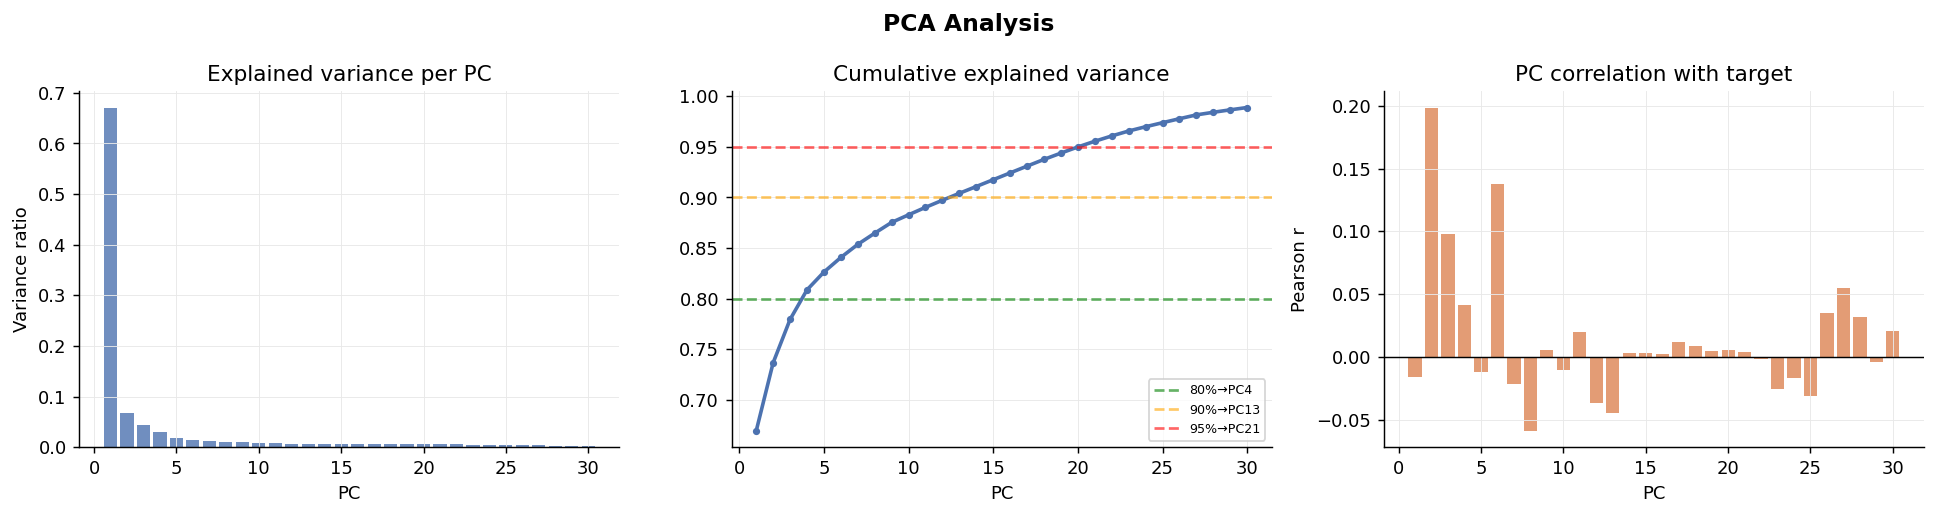

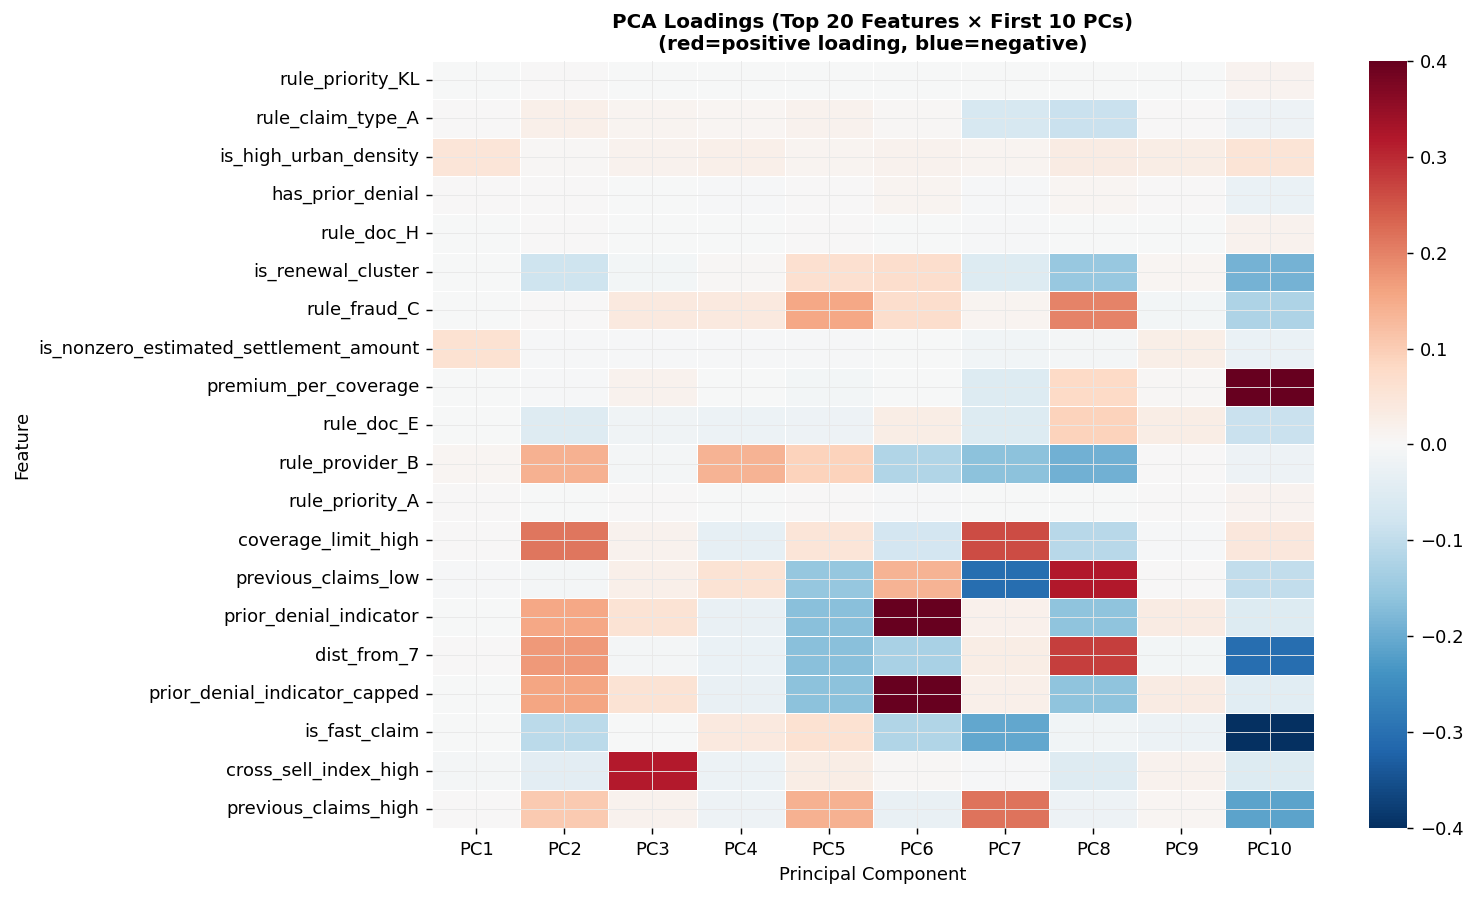

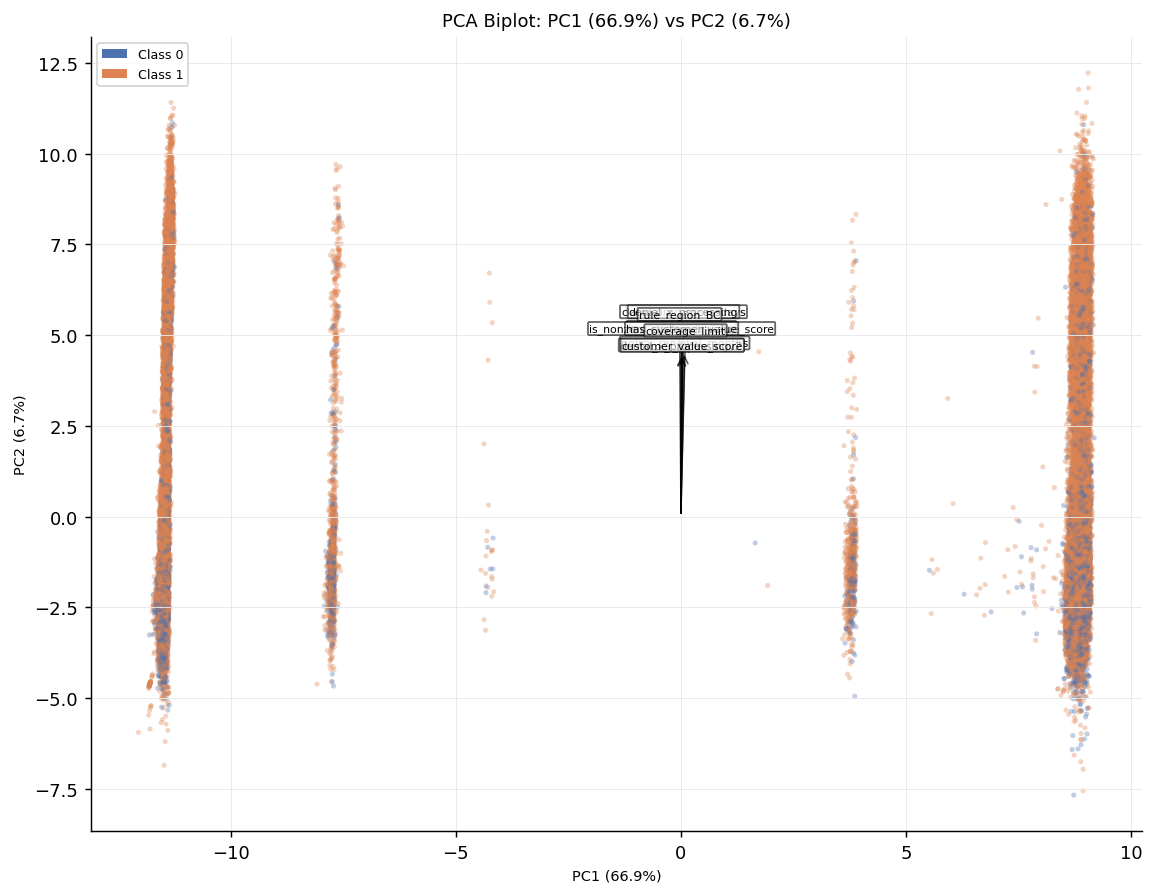


────────────────────────────────────────────────────────────
  Top 5 features loading on each PC (first 5 PCs):
────────────────────────────────────────────────────────────

  PC1  (explains 66.95%):
    +0.0999  income_bracket_index
    +0.0999  model_version_indicator
    +0.0999  days_in_current_status
    +0.0999  third_party_involved_count
    +0.0999  salvage_value

  PC2  (explains 6.73%):
    +0.2724  claim_processing_days
    +0.2724  denial_x_processing
    +0.2688  rule_region_BC
    +0.2515  is_zero_touchpoints
    +0.2501  is_nonzero_customer_value_score

  PC3  (explains 4.28%):
    +0.3768  cross_sell_index
    +0.3768  cross_sell_dist_15
    +0.3756  cross_sell_sigmoid
    +0.3752  policy_premium_annual
    -0.3738  incurred_loss_estimate

  PC4  (explains 2.92%):
    +0.4465  recovery_probability
    -0.4058  recovery_prob_low
    +0.3718  recovery_prob_mid
    -0.3195  recovery_prob_is_one
    -0.2642  communication_touchpoints_flipped

  PC5  (explains 1.76%):
    +

In [14]:
pca_out = run_pca_full(X_train, y_train_numeric, n_components=30)
# → pca_out["pca"], pca_out["Z"], pca_out["loadings_df"]


#### KERNEL PCA (non-linear PCA)

In [21]:






def run_kernel_pca(
    X:          pd.DataFrame,
    y:          pd.Series | np.ndarray | None = None,
    n_components: int = 2,
    kernels:    list[str] = ["linear", "rbf", "poly", "sigmoid", "cosine"],
    gamma:      float = 0.01,
    save_path:  str | None = None,
) -> dict:
    """
    Runs Kernel PCA with multiple kernels and plots 2-D projections.
    Use to check if non-linear structure exists beyond PCA.
    """
    Xs, _ = _scale(X)
    n_sub  = min(5000, len(Xs))   # KPCA is O(n²) — subsample for speed
    idx    = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_sub = Xs[idx]
    y_sub  = np.asarray(y)[idx] if y is not None else None

    results = {}
    n_k = len(kernels)
    fig, axes = plt.subplots(1, n_k, figsize=(5 * n_k, 4))
    if n_k == 1:
        axes = [axes]
    fig.suptitle("Kernel PCA — 2D Projections Across Kernels",
                 fontsize=12, fontweight="bold")

    for ax, kernel in zip(axes, kernels):
        try:
            kpca = KernelPCA(n_components=n_components, kernel=kernel,
                             gamma=gamma, random_state=42)
            Z    = kpca.fit_transform(Xs_sub)
            _scatter2d(ax, Z, y_sub, f"Kernel PCA\n({kernel})")
            results[kernel] = Z
        except Exception as e:
            ax.set_title(f"{kernel}\n(failed: {e})", fontsize=8)

    fig.tight_layout()
    _save(fig, save_path, "DR_05_kernel_pca.png")


    return results

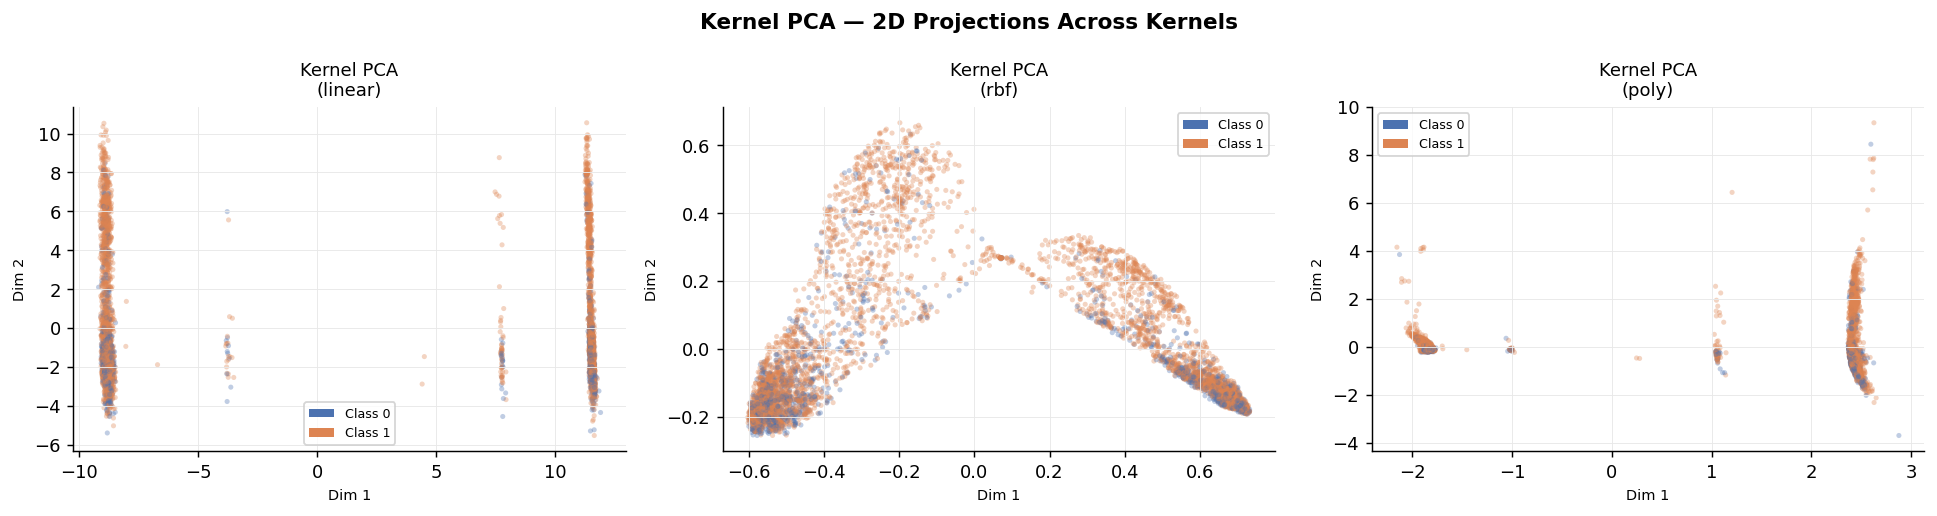

In [24]:
kernel_pca_out = run_kernel_pca(X_train, y_train_numeric, n_components=2, kernels=["linear", "rbf", "poly"], gamma=0.01)

#### Factor Analysis

In [17]:
def run_factor_analysis(
    X:           pd.DataFrame,
    y:           pd.Series | np.ndarray | None = None,
    n_factors:   int = 10,
    save_path:   str | None = None,
) -> dict:
    """
    Factor Analysis: finds latent factors that explain covariance structure.
    Particularly useful for this dataset because the r>0.97 correlation clusters
    are exactly the kind of structure FA is designed to recover.

    Unlike PCA (maximises variance), FA maximises explained covariance.
    """
    Xs, feat_names = _scale(X)
    n_factors = min(n_factors, Xs.shape[1] - 1)

    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    Z  = fa.fit_transform(Xs)

    loadings  = pd.DataFrame(fa.components_.T,
                              index=feat_names,
                              columns=[f"F{i+1}" for i in range(n_factors)])
    communal  = (loadings ** 2).sum(axis=1)   # communality per feature
    uniqueness = fa.noise_variance_

    # ── Loadings heatmap ────────────────────────────────────────────────
    top_feats = communal.nlargest(20).index
    sub       = loadings.loc[top_feats, :]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle("Factor Analysis", fontsize=13, fontweight="bold")

    sns.heatmap(sub, cmap="RdBu_r", center=0, linewidths=0.3,
                annot=False, ax=axes[0], vmin=-0.6, vmax=0.6)
    axes[0].set_title("Factor Loadings\n(top 20 features by communality)")
    axes[0].set_xlabel("Factor")
    axes[0].set_ylabel("Feature")

    # Communality bar chart
    communal.nlargest(20).sort_values().plot(
        kind="barh", ax=axes[1], color=_C0, alpha=0.8
    )
    axes[1].set_title("Communality per Feature\n"
                      "(fraction of variance explained by factors)")
    axes[1].set_xlabel("Communality")

    fig.tight_layout()
    _save(fig, save_path, "DR_06_factor_analysis.png")

    # ── 2D scatter: Factor 1 vs Factor 2 ────────────────────────────────
    fig2, ax2 = plt.subplots(figsize=(7, 5))
    _scatter2d(ax2, Z, y,
               "Factor Analysis — F1 vs F2", "Factor 1", "Factor 2")
    fig2.tight_layout()
    _save(fig2, save_path, "DR_07_fa_scatter.png")

    print(f"\n  Factor Analysis: top communalities (well-explained features):")
    print(communal.nlargest(10).round(4).to_string())
    print(f"\n  Features with low communality (poorly explained by factors):")
    print(communal.nsmallest(5).round(4).to_string())

    return {"fa": fa, "Z": Z, "loadings": loadings, "communality": communal}

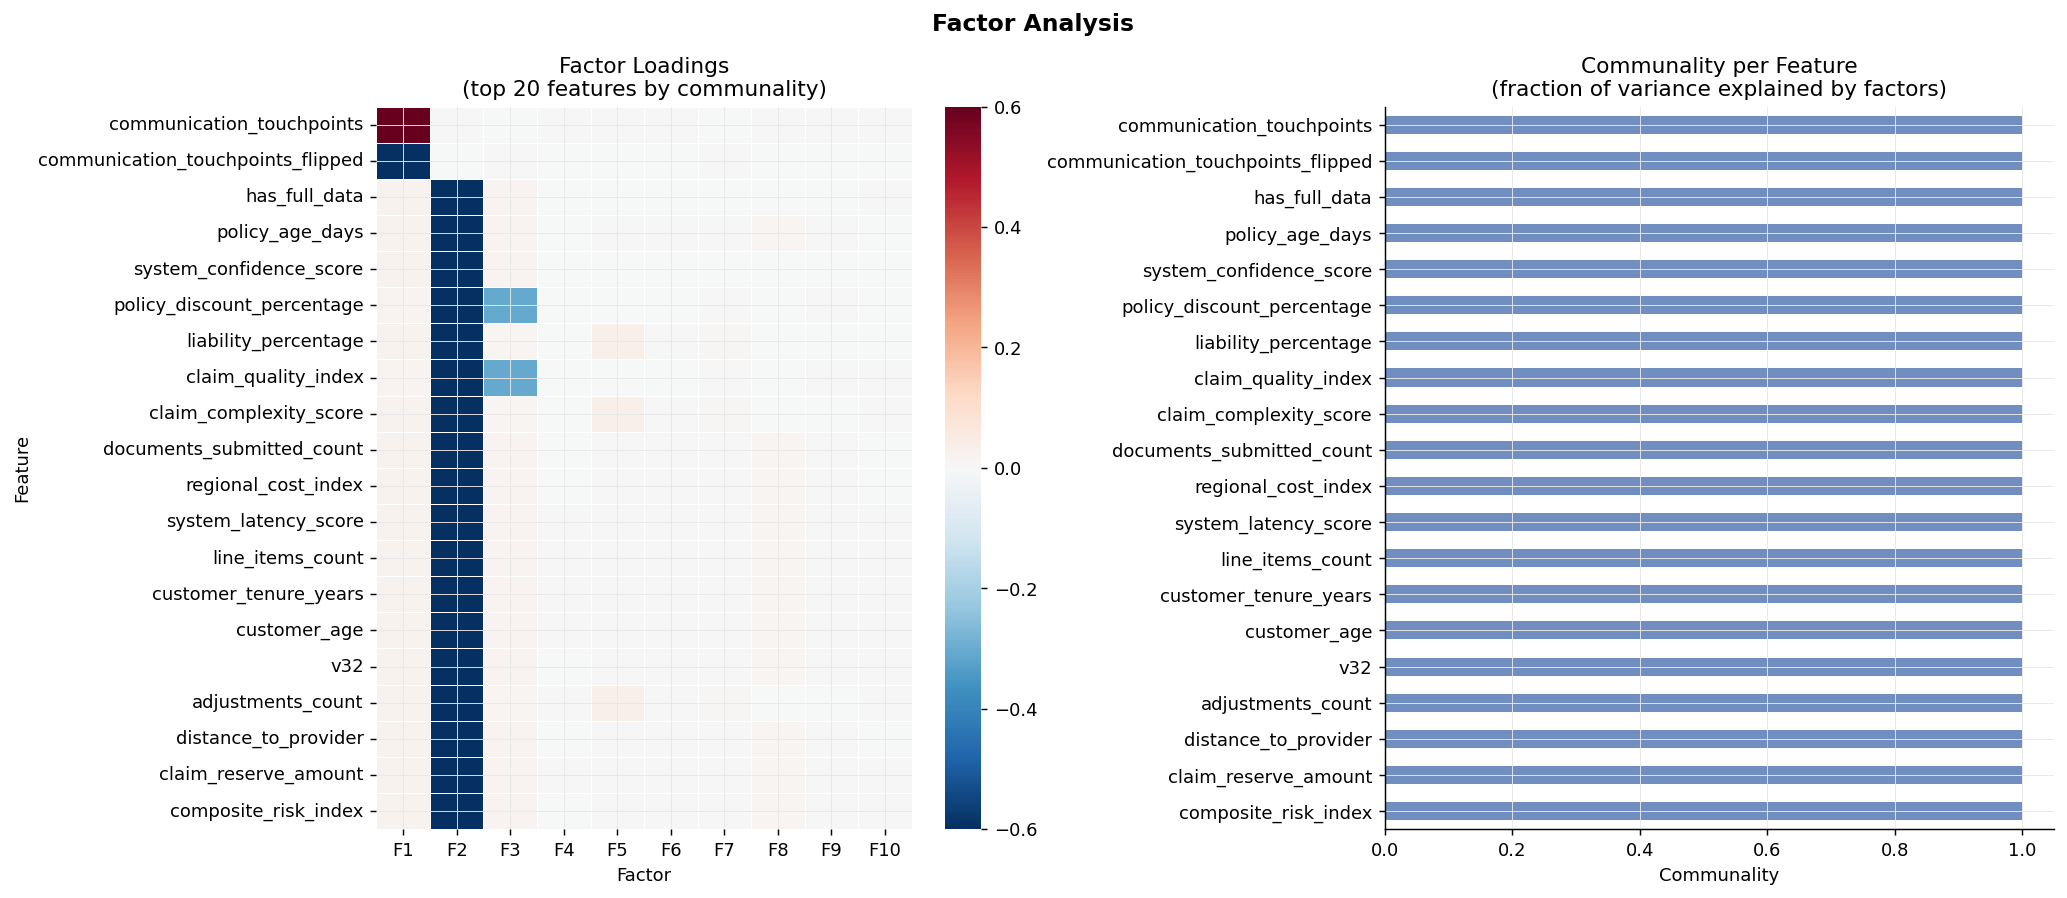

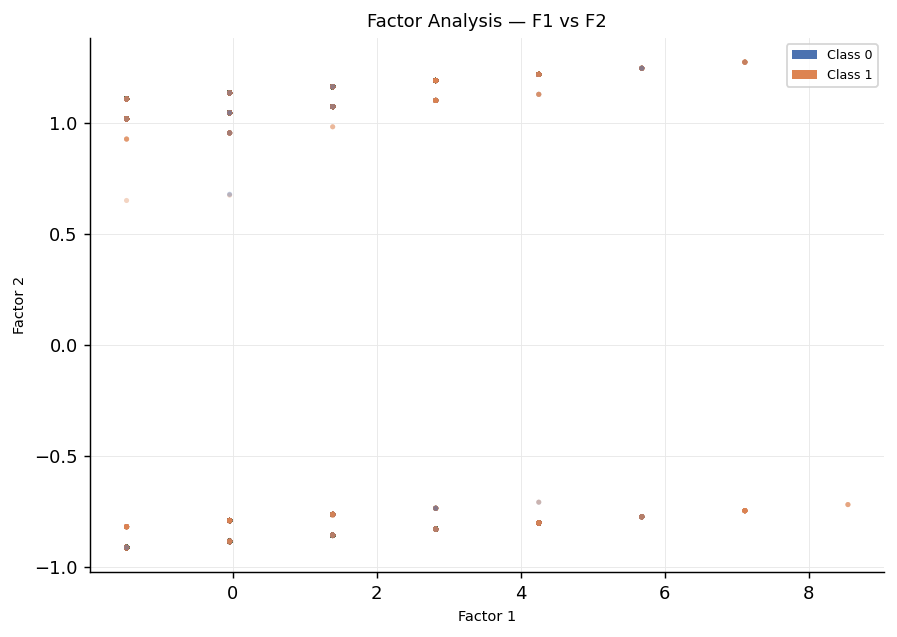


  Factor Analysis: top communalities (well-explained features):
communication_touchpoints            1.0
communication_touchpoints_flipped    1.0
has_full_data                        1.0
policy_age_days                      1.0
system_confidence_score              1.0
policy_discount_percentage           1.0
liability_percentage                 1.0
claim_quality_index                  1.0
claim_complexity_score               1.0
documents_submitted_count            1.0

  Features with low communality (poorly explained by factors):
is_renewal_month_7      0.0000
rule_priority_KL        0.0000
rule_doc_H              0.0001
premium_per_coverage    0.0001
rule_priority_A         0.0001


In [25]:
factor_analysis_out = run_factor_analysis(X_train, y_train_numeric, n_factors=10)

#### NMF (Non-negative Matrix Factorisation)

In [26]:
def run_nmf(
    X:           pd.DataFrame,
    y:           pd.Series | np.ndarray | None = None,
    n_components: int = 10,
    save_path:   str | None = None,
) -> dict:
    """
    NMF decomposes X ≈ W × H where W, H ≥ 0.
    Produces parts-based representation — each component is a
    non-negative additive combination of features.

    Note: requires non-negative input. We min-max shift the data.
    """
    Xs, feat_names = _scale(X, method="robust")
    # Shift to non-negative
    Xs = Xs - Xs.min(axis=0)

    n_components = min(n_components, Xs.shape[1])
    nmf = NMF(n_components=n_components, random_state=42, max_iter=500)
    W   = nmf.fit_transform(Xs)      # sample weights (n_samples × k)
    H   = nmf.components_            # component loadings (k × n_features)

    loadings = pd.DataFrame(H.T, index=feat_names,
                             columns=[f"NMF{i+1}" for i in range(n_components)])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Non-negative Matrix Factorisation (NMF)",
                 fontsize=12, fontweight="bold")

    # Top loadings for first 5 components
    top5_load = loadings[[f"NMF{i+1}" for i in range(min(5, n_components))]].head(20)
    sns.heatmap(top5_load, cmap="YlOrRd", linewidths=0.3,
                annot=False, ax=axes[0])
    axes[0].set_title("NMF Loadings (first 5 components)")

    # 2D scatter
    _scatter2d(axes[1], W, y, "NMF — Component 1 vs 2",
               "NMF1", "NMF2")

    fig.tight_layout()
    _save(fig, save_path, "DR_08_nmf.png")

    return {"nmf": nmf, "W": W, "H": H, "loadings": loadings}



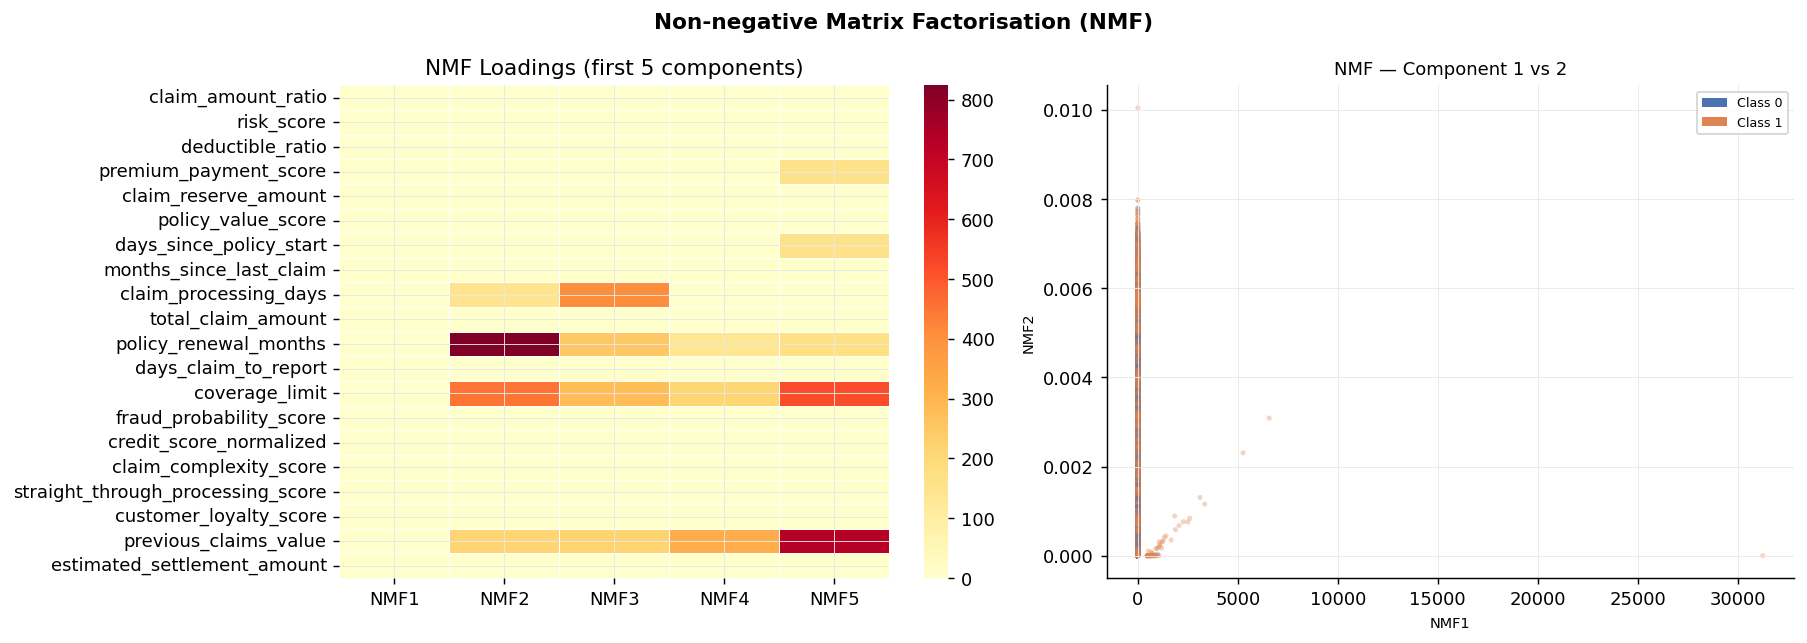

In [27]:
nmf_out = run_nmf(X_train, y_train_numeric, n_components=10)

#### t-SNE

In [28]:
def run_tsne(
    X:           pd.DataFrame,
    y:           pd.Series | np.ndarray | None = None,
    perplexities: list[int] = [5, 30, 50, 100],
    n_components: int = 2,
    n_samples:   int = 8000,
    pca_init_dims: int = 50,
    save_path:   str | None = None,
) -> dict:
    """
    t-SNE with multiple perplexity values for robustness.
    PCA initialisation is used for reproducibility and speed.

    Perplexity interpretation:
      low  (5–15) : focuses on very local structure
      mid  (30–50): standard, good balance
      high (100+) : more global structure

    Note: t-SNE distances are NOT meaningful — only topology matters.
    """
    Xs, _ = _scale(X)

    # Subsample
    n_sub = min(n_samples, len(Xs))
    idx   = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s  = Xs[idx]
    y_s   = np.asarray(y)[idx] if y is not None else None

    # PCA initialisation (reduces noise, speeds up t-SNE)
    k_init = min(pca_init_dims, Xs_s.shape[1])
    Z_pca  = PCA(n_components=k_init, random_state=42).fit_transform(Xs_s)

    results = {}
    n_p    = len(perplexities)
    fig, axes = plt.subplots(1, n_p, figsize=(5 * n_p, 4))
    if n_p == 1:
        axes = [axes]
    fig.suptitle(f"t-SNE — n={n_sub:,} samples,  comparing perplexities",
                 fontsize=12, fontweight="bold")

    for ax, perp in zip(axes, perplexities):
        tsne = TSNE(
            n_components = n_components,
            perplexity   = min(perp, n_sub - 1),
            init         = "pca" if k_init >= n_components else "random",
            learning_rate= "auto",
            random_state = 42,
            n_jobs       = -1,
        )
        try:
            Z = tsne.fit_transform(Z_pca)
            _scatter2d(ax, Z, y_s, f"t-SNE  perp={perp}\n(KL={tsne.kl_divergence_:.3f})")
            results[perp] = Z
        except Exception as e:
            ax.set_title(f"perp={perp}\nFailed: {e}", fontsize=8)

    fig.tight_layout()
    _save(fig, save_path, "DR_09_tsne.png")


    return results



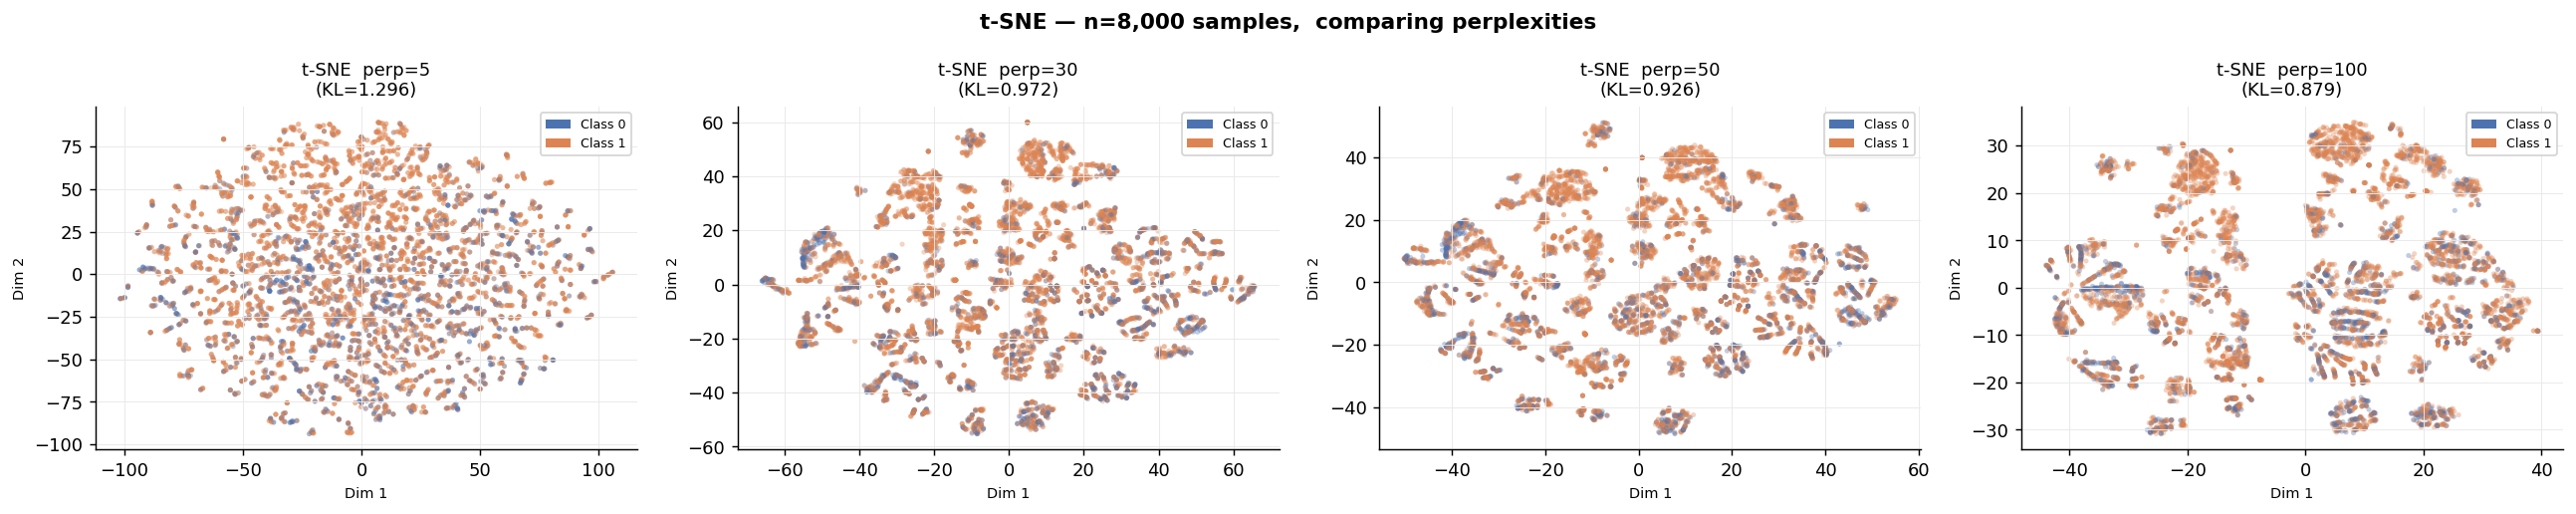

In [42]:
tsne_out = run_tsne(X_train, y_train_numeric, perplexities=[5, 30, 50, 100], n_components=2, n_samples=8000, pca_init_dims=50)

### UMAP

In [35]:
def run_umap(
    X:             pd.DataFrame,
    y:             pd.Series | np.ndarray | None = None,
    n_neighbors_list: list[int] = [5, 15, 30, 50],
    min_dist_list:    list[float] = [0.0, 0.1, 0.5],
    n_components:  int   = 2,
    n_samples:     int   = 10000,
    save_path:     str | None = None,
) -> dict:
    """
    UMAP with multiple (n_neighbors, min_dist) combinations.

    n_neighbors : controls local vs global structure
      small (5–10)  : local structure, fragmented
      large (50+)   : global structure, smoother

    min_dist    : how tightly points cluster in embedding
      0.0 = tight clumps (better for clustering)
      0.5 = spread out (better for topology)

    UMAP advantage over t-SNE:
      - Faster on large datasets
      - Preserves global structure better
      - More interpretable parameter space
    """
    try:
        import umap
    except ImportError:
        print("  ⚠️  UMAP not installed. Run: pip install umap-learn")
        return {}

    Xs, _ = _scale(X)
    n_sub  = min(n_samples, len(Xs))
    idx    = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s   = Xs[idx]
    y_s    = np.asarray(y)[idx] if y is not None else None

    results = {}

    # ── Grid: n_neighbors vs min_dist ────────────────────────────────────
    combos  = [(n, d) for n in n_neighbors_list for d in min_dist_list]
    n_c     = len(combos)
    n_cols  = len(min_dist_list)
    n_rows  = len(n_neighbors_list)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(n_rows, n_cols)
    fig.suptitle(f"UMAP — n={n_sub:,} samples  (rows=n_neighbors, cols=min_dist)",
                 fontsize=12, fontweight="bold")

    for ri, n_nb in enumerate(n_neighbors_list):
        for ci, min_d in enumerate(min_dist_list):
            ax = axes[ri, ci]
            try:
                reducer = umap.UMAP(
                    n_neighbors  = min(n_nb, n_sub - 1),
                    min_dist     = min_d,
                    n_components = n_components,
                    random_state = 42,
                    n_jobs       = -1,
                )
                Z = reducer.fit_transform(Xs_s)
                _scatter2d(ax, Z, y_s,
                           f"n_nb={n_nb}  min_d={min_d}")
                results[(n_nb, min_d)] = Z
            except Exception as e:
                ax.set_title(f"n_nb={n_nb} min_d={min_d}\n{e}", fontsize=7)

    fig.tight_layout()
    _save(fig, save_path, "DR_10_umap_grid.png")

    # ── Best single UMAP for report ────────────────────────────────────────
    best_key = (15, 0.1)
    if best_key in results:
        fig2, ax2 = plt.subplots(figsize=(8, 6))
        _scatter2d(ax2, results[best_key], y_s,
                   f"UMAP  n_neighbors=15  min_dist=0.1\n(n={n_sub:,} samples)",
                   "UMAP-1", "UMAP-2")
        fig2.tight_layout()
        _save(fig2, save_path, "DR_11_umap_best.png")

    print("\n  UMAP interpretation guide:")
    print("  → Tight class-coloured blobs → strong global cluster structure")
    print("  → More structure than t-SNE at same settings → global preserved")
    print("  → Use n_neighbors=15, min_dist=0.1 as the 'standard' setting")

    return results

2026-05-24 22:28:25.507580: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-24 22:28:25.594523: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779658105.626466   21832 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779658105.635903   21832 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779658105.714460   21832 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

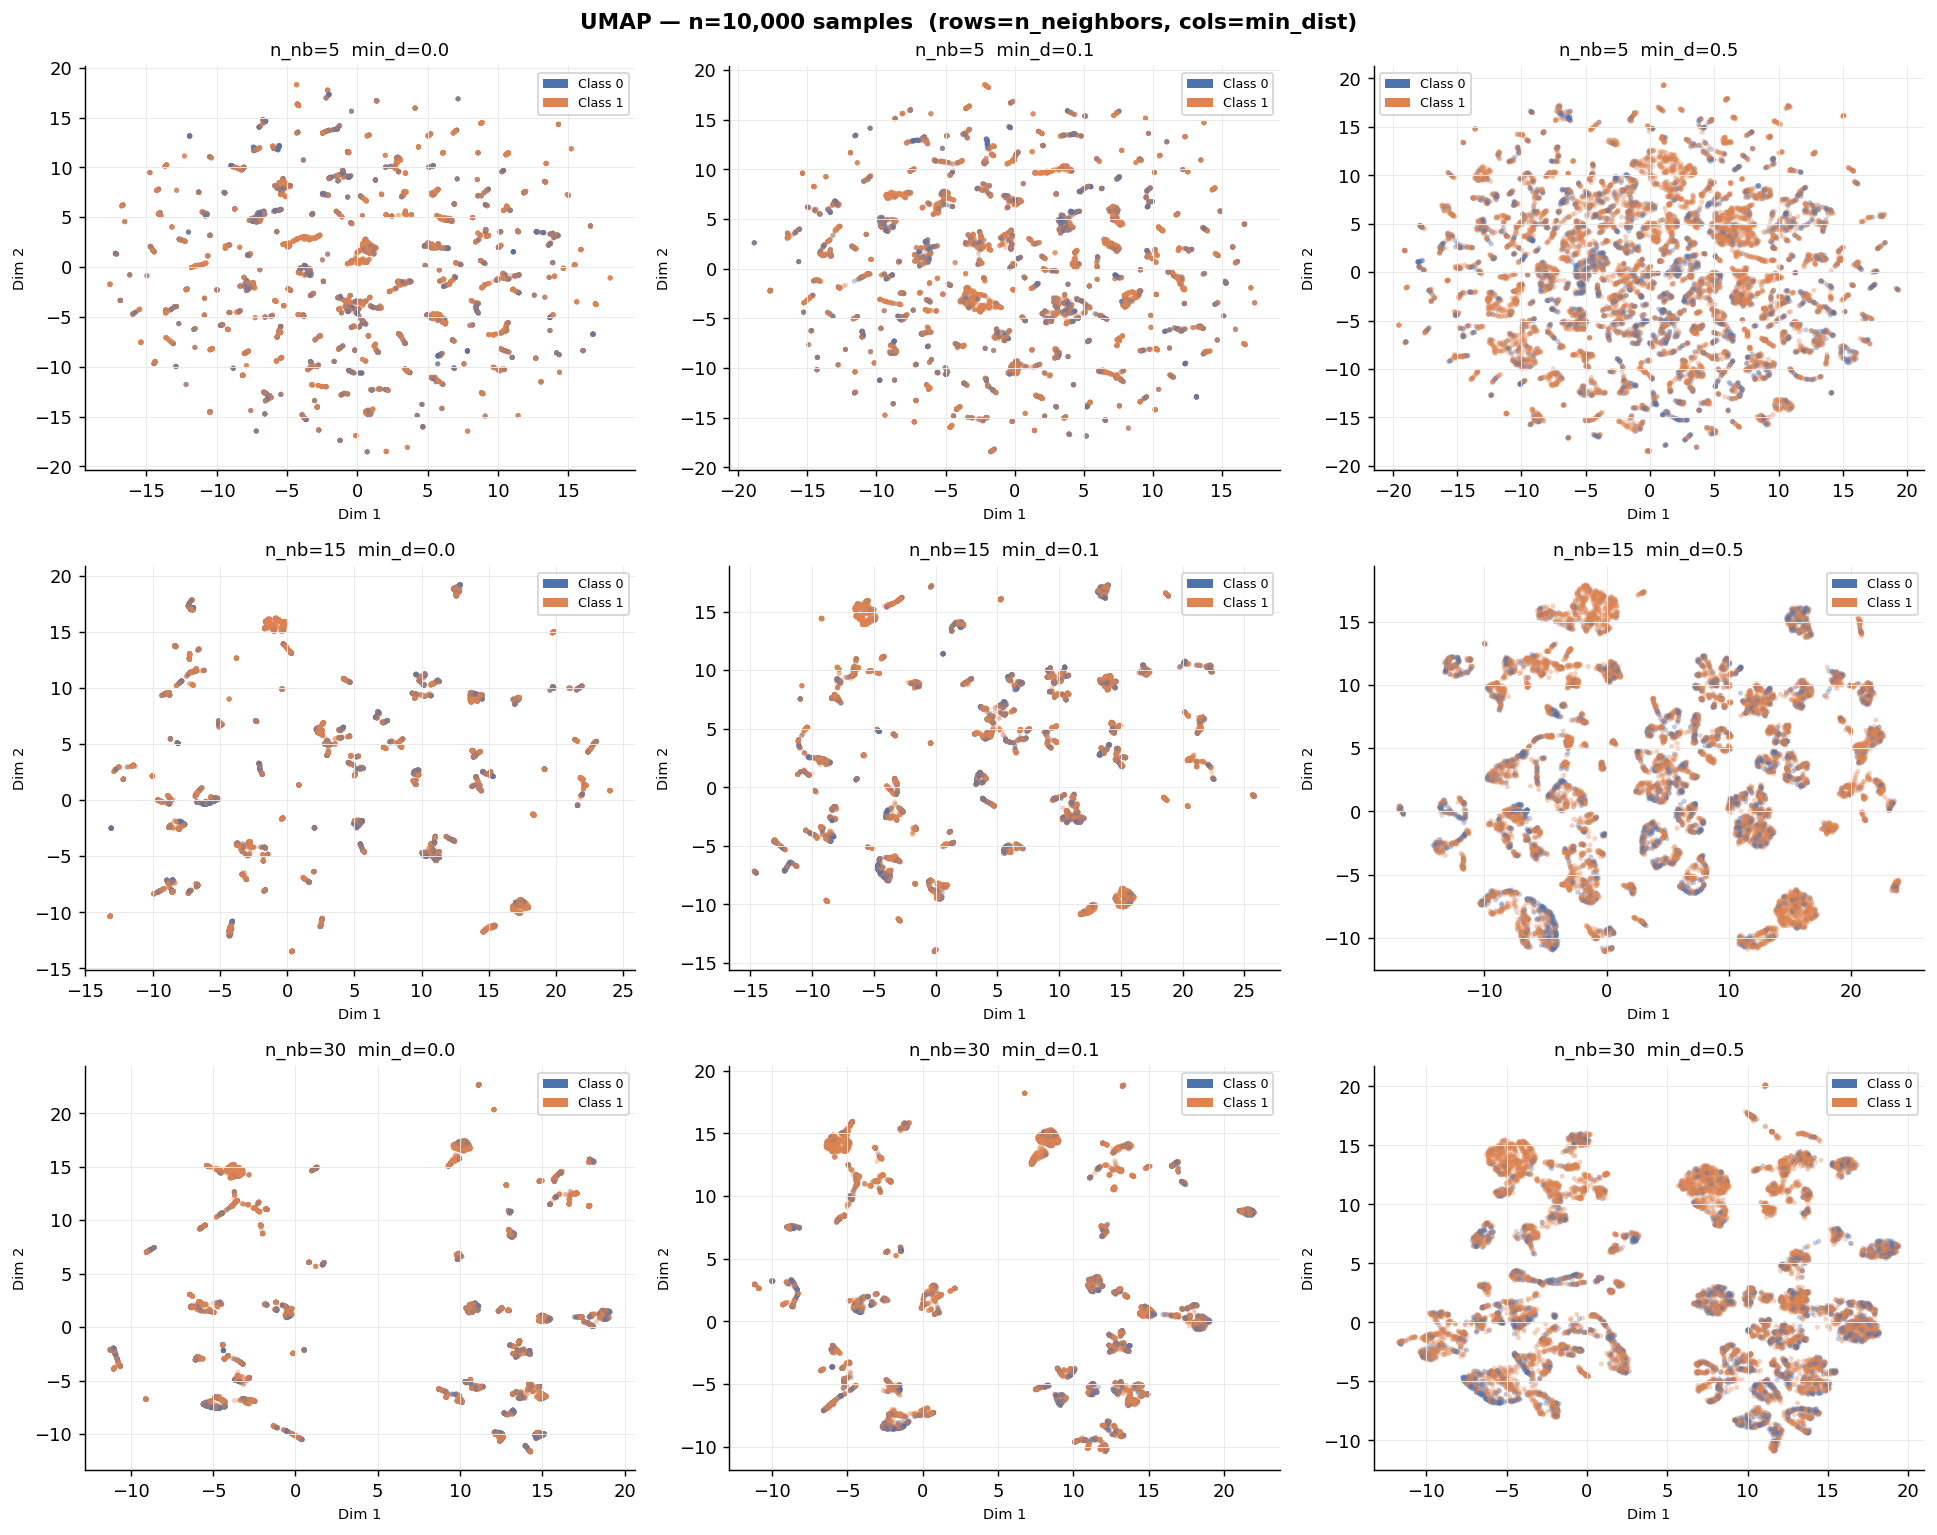

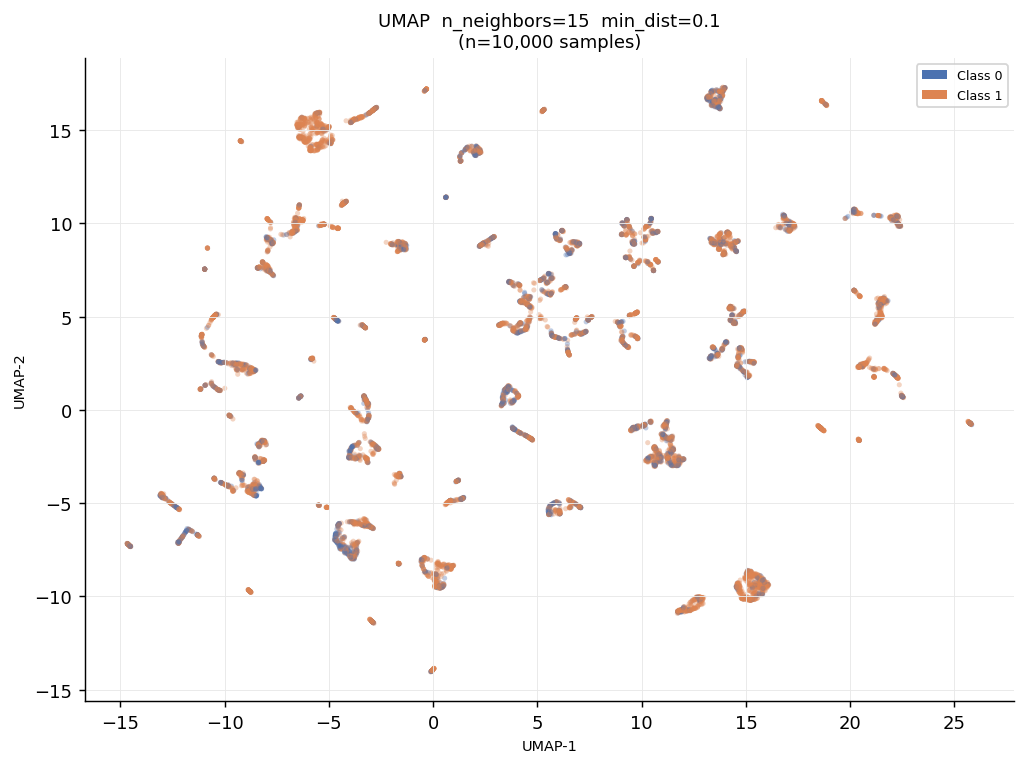


  UMAP interpretation guide:
  → Tight class-coloured blobs → strong global cluster structure
  → More structure than t-SNE at same settings → global preserved
  → Use n_neighbors=15, min_dist=0.1 as the 'standard' setting


{(5,
  0.0): array([[ 0.69681525,  0.45526814],
        [-7.094926  , 11.819198  ],
        [ 0.10498489, -4.2022543 ],
        ...,
        [-2.6217065 , -6.893033  ],
        [-2.4599404 , 13.437991  ],
        [-8.068355  , 10.025388  ]], dtype=float32),
 (5,
  0.1): array([[ -2.4738314,  -4.3722053],
        [ -6.4069643,  12.8664255],
        [  3.5630689,  -3.4472673],
        ...,
        [ -2.3956676, -15.1610155],
        [ -7.5605497,   9.797916 ],
        [ -9.049447 ,  -8.365454 ]], dtype=float32),
 (5,
  0.5): array([[ 5.1618247,  6.079805 ],
        [-2.0659356, -6.2887163],
        [-1.4048162, -3.3334854],
        ...,
        [ 9.249004 , -3.9319973],
        [ 5.081891 , -4.3678646],
        [-2.3257294,  3.1281092]], dtype=float32),
 (15,
  0.0): array([[ 16.77363  ,  -9.579506 ],
        [ -7.788453 ,  -2.2990866],
        [ 10.907309 ,  -3.8335128],
        ...,
        [ 13.783977 ,   4.368987 ],
        [  5.667176 ,  -4.5356045],
        [  2.5270743, -11.123293

In [36]:


run_umap(X_train, y_train_numeric, n_neighbors_list=[5, 15, 30], min_dist_list=[0.0, 0.1, 0.5], n_components=2, n_samples=10000)

### LLE

In [38]:
def run_lle(
    X:          pd.DataFrame,
    y:          pd.Series | np.ndarray | None = None,
    n_neighbors_list: list[int] = [5, 10, 20, 30],
    methods:    list[str] = ["standard", "modified", "hessian"],
    n_samples:  int = 3000,
    save_path:  str | None = None,
) -> dict:
    """
    Locally Linear Embedding — manifold learning.
    Assumes the data lies on a smooth low-dimensional manifold.

    Methods:
      standard  : original LLE — fast but sensitive to noise
      modified  : regularised, more robust
      hessian   : uses Hessian eigenmaps, best for curved manifolds
                  (requires n_neighbors > n_components*(n_components+3)/2)
    """
    Xs, _ = _scale(X)
    n_sub  = min(n_samples, len(Xs))
    idx    = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s   = Xs[idx]
    y_s    = np.asarray(y)[idx] if y is not None else None

    results = {}
    combos  = [(m, nb) for m in methods for nb in n_neighbors_list]
    n_c     = len(combos)

    fig, axes = plt.subplots(len(methods), len(n_neighbors_list),
                             figsize=(4 * len(n_neighbors_list),
                                      3.5 * len(methods)))
    axes = np.array(axes).reshape(len(methods), len(n_neighbors_list))
    fig.suptitle(f"LLE — n={n_sub:,}  (rows=method, cols=n_neighbors)",
                 fontsize=12, fontweight="bold")

    for ri, method in enumerate(methods):
        for ci, nb in enumerate(n_neighbors_list):
            ax = axes[ri, ci]
            try:
                min_nb = (2 + 3 + 1 if method == "hessian"
                          else nb)   # hessian needs extra neighbours
                lle = LocallyLinearEmbedding(
                    n_components = 2,
                    n_neighbors  = max(min_nb, nb),
                    method       = method,
                    random_state = 42,
                )
                Z = lle.fit_transform(Xs_s)
                _scatter2d(ax, Z, y_s,
                           f"{method}  nb={nb}\nerr={lle.reconstruction_error_:.4f}")
                results[(method, nb)] = Z
            except Exception as e:
                ax.set_title(f"{method} nb={nb}\n{str(e)[:40]}", fontsize=7)

    fig.tight_layout()
    _save(fig, save_path, "DR_12_lle.png")

    return results

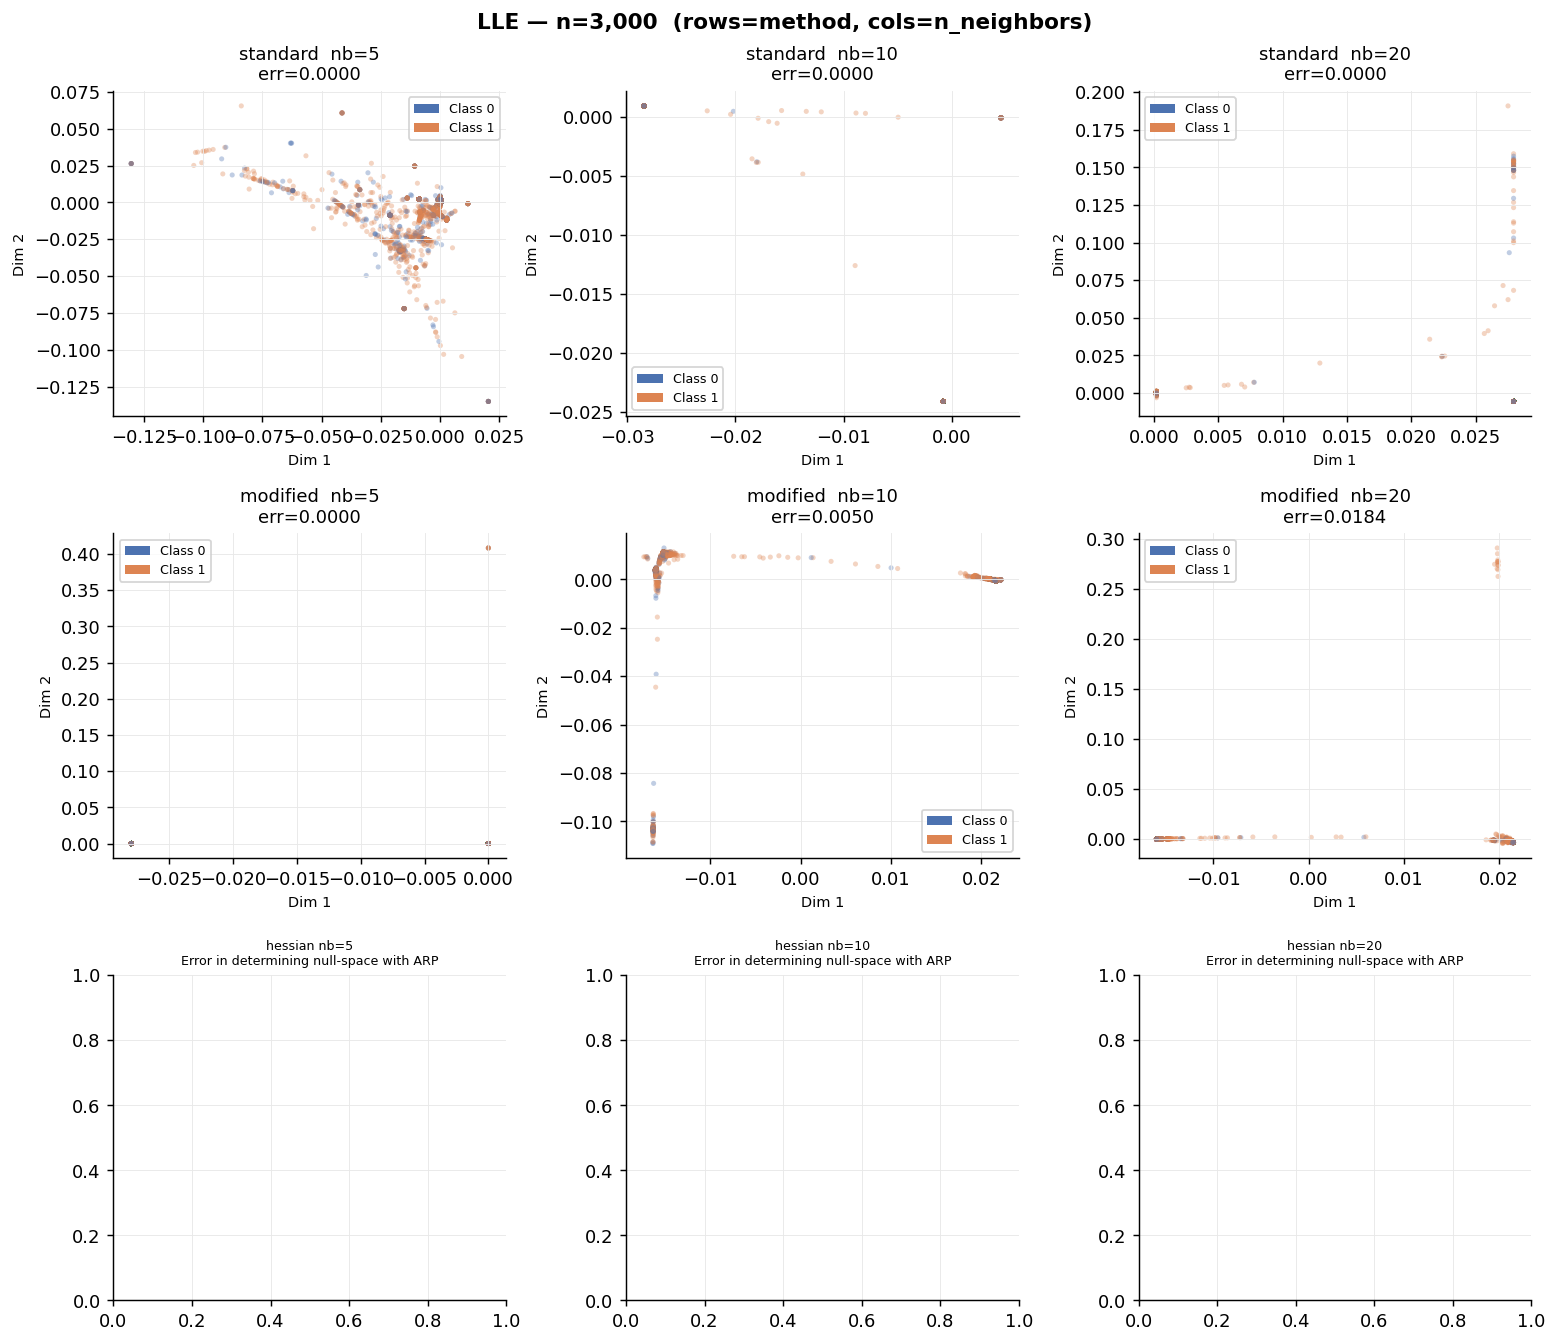

In [39]:
lle_out = run_lle(X_train, y_train_numeric, n_neighbors_list=[5, 10, 20], methods=["standard", "modified", "hessian"], n_samples=3000)

### ISOMAP

In [40]:
def run_isomap(
    X:          pd.DataFrame,
    y:          pd.Series | np.ndarray | None = None,
    n_neighbors_list: list[int] = [5, 10, 20, 50],
    n_samples:  int = 3000,
    save_path:  str | None = None,
) -> dict:
    """
    Isomap — geodesic distance manifold learning.
    Better than LLE for curved manifolds with few holes.
    Sensitive to n_neighbors.
    """
    Xs, _ = _scale(X)
    n_sub  = min(n_samples, len(Xs))
    idx    = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s   = Xs[idx]
    y_s    = np.asarray(y)[idx] if y is not None else None

    results = {}
    n_k = len(n_neighbors_list)
    fig, axes = plt.subplots(1, n_k, figsize=(5 * n_k, 4))
    if n_k == 1: axes = [axes]
    fig.suptitle(f"Isomap — n={n_sub:,}  varying n_neighbors",
                 fontsize=12, fontweight="bold")

    for ax, nb in zip(axes, n_neighbors_list):
        try:
            iso = Isomap(n_components=2, n_neighbors=nb)
            Z   = iso.fit_transform(Xs_s)
            _scatter2d(ax, Z, y_s, f"Isomap  n_neighbors={nb}")
            results[nb] = Z
        except Exception as e:
            ax.set_title(f"nb={nb}\n{e}", fontsize=8)

    fig.tight_layout()
    _save(fig, save_path, "DR_13_isomap.png")

    return results


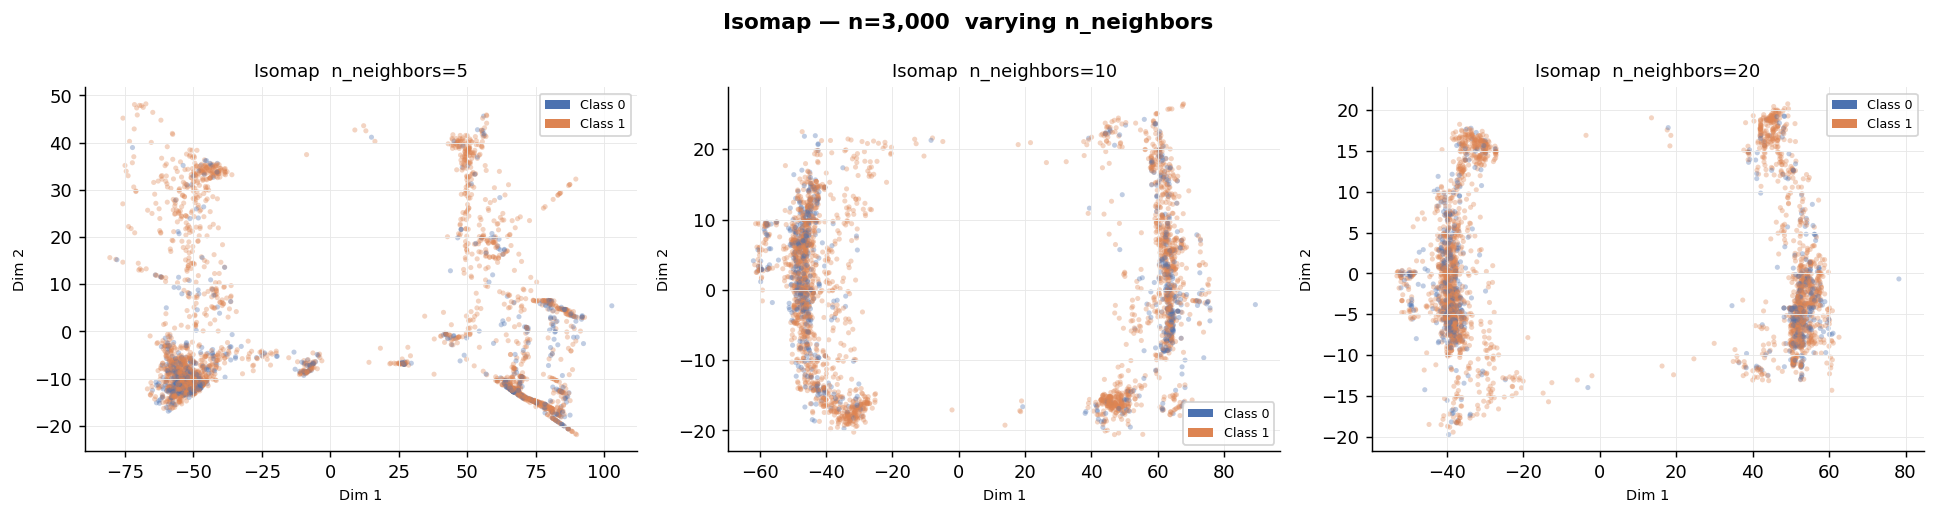

In [41]:
isomap_out = run_isomap(X_train, y_train_numeric, n_neighbors_list=[5, 10, 20], n_samples=3000)

### 

In [43]:
def run_mds(
    X:         pd.DataFrame,
    y:         pd.Series | np.ndarray | None = None,
    n_samples: int = 2000,
    save_path: str | None = None,
) -> dict:
    """
    MDS — preserves pairwise distances in the embedding.
    Metric MDS: uses Euclidean distances (similar to PCA, linear).
    Non-metric MDS: uses only rank order of distances (more flexible).
    """
    Xs, _ = _scale(X)
    n_sub  = min(n_samples, len(Xs))
    idx    = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s   = Xs[idx]
    y_s    = np.asarray(y)[idx] if y is not None else None

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"MDS — n={n_sub:,}", fontsize=12, fontweight="bold")

    results = {}
    for ax, metric, label in [
        (axes[0], True,  "Metric MDS (Euclidean)"),
        (axes[1], False, "Non-metric MDS (rank-based)"),
    ]:
        try:
            mds = MDS(n_components=2, metric=metric, random_state=42,
                      n_jobs=-1)
            Z   = mds.fit_transform(Xs_s)
            _scatter2d(ax, Z, y_s,
                       f"{label}\nstress={mds.stress_:.2f}")
            results[label] = Z
        except Exception as e:
            ax.set_title(f"{label}\n{e}", fontsize=8)

    fig.tight_layout()
    _save(fig, save_path, "DR_14_mds.png")

    print("\n  MDS stress interpretation:")
    print("  < 0.05  excellent  | 0.05–0.10  good")
    print("  0.10–0.20  fair    | > 0.20  poor fit")

    return results

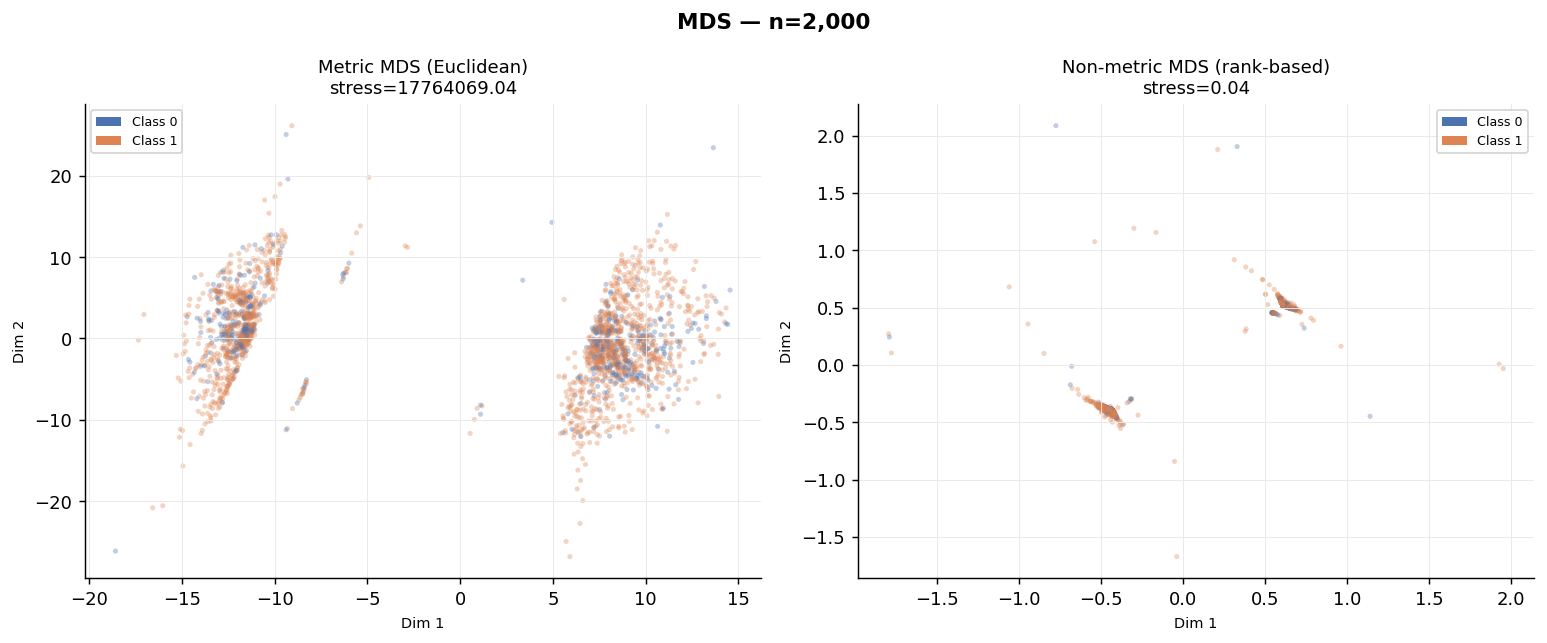


  MDS stress interpretation:
  < 0.05  excellent  | 0.05–0.10  good
  0.10–0.20  fair    | > 0.20  poor fit


In [44]:
mds_out = run_mds(X_train, y_train_numeric, n_samples=2000)

### Autoencoder

In [45]:
def run_autoencoder(
    X:           pd.DataFrame,
    y:           pd.Series | np.ndarray | None = None,
    encoding_dim: int  = 2,
    hidden_dims: list[int] = [128, 64, 32],
    epochs:      int  = 50,
    batch_size:  int  = 256,
    learning_rate: float = 1e-3,
    save_path:   str | None = None,
) -> dict:
    """
    Variational Autoencoder (VAE) / standard Autoencoder for
    non-linear dimensionality reduction.

    Architecture:
      Input → [128 → 64 → 32] → encoding_dim → [32 → 64 → 128] → Output

    encoding_dim=2  → 2-D visualisation (like t-SNE but trainable)
    encoding_dim=k  → k-dimensional representation for downstream use

    Requires PyTorch. Falls back to sklearn MLPRegressor if not available.
    """
    Xs, _ = _scale(X)
    n, d   = Xs.shape

    try:
        import torch
        import torch.nn as nn
        from torch.utils.data import DataLoader, TensorDataset

        X_tensor = torch.FloatTensor(Xs)
        loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size,
                              shuffle=True)

        # ── Build encoder-decoder ────────────────────────────────────────
        def build_layers(dims):
            layers = []
            for i in range(len(dims) - 1):
                layers.extend([
                    nn.Linear(dims[i], dims[i+1]),
                    nn.BatchNorm1d(dims[i+1]),
                    nn.LeakyReLU(0.1),
                    nn.Dropout(0.1),
                ])
            return nn.Sequential(*layers)

        encoder_dims  = [d] + hidden_dims + [encoding_dim]
        decoder_dims  = [encoding_dim] + list(reversed(hidden_dims)) + [d]

        encoder = build_layers(encoder_dims)
        decoder = build_layers(decoder_dims[:-1])
        decoder = nn.Sequential(decoder, nn.Linear(decoder_dims[-2], decoder_dims[-1]))

        class Autoencoder(nn.Module):
            def __init__(self):
                super().__init__()
                self.encoder = encoder
                self.decoder = decoder
            def forward(self, x):
                z     = self.encoder(x)
                x_hat = self.decoder(z)
                return x_hat, z

        model     = Autoencoder()
        optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
        criterion = nn.MSELoss()

        # ── Training loop ────────────────────────────────────────────────
        losses = []
        model.train()
        for ep in range(epochs):
            ep_loss = 0.0
            for (batch,) in loader:
                optimiser.zero_grad()
                recon, _ = model(batch)
                loss      = criterion(recon, batch)
                loss.backward()
                optimiser.step()
                ep_loss += loss.item() * len(batch)
            losses.append(ep_loss / n)
            if (ep + 1) % 10 == 0:
                print(f"    Epoch {ep+1}/{epochs}  loss={losses[-1]:.6f}")

        # ── Extract embeddings ───────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            _, Z_tensor = model(X_tensor)
        Z = Z_tensor.numpy()

        # ── Plots ────────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"Autoencoder  encoding_dim={encoding_dim}",
                     fontsize=12, fontweight="bold")

        axes[0].plot(losses, color=_C0, linewidth=2)
        axes[0].set_title("Training Loss (MSE)")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")

        if encoding_dim == 2:
            _scatter2d(axes[1], Z, y, "Autoencoder 2-D Embedding",
                       "Dim 1", "Dim 2")
        else:
            pca2 = PCA(n_components=2, random_state=42)
            Z2   = pca2.fit_transform(Z)
            _scatter2d(axes[1], Z2, y,
                       f"Autoencoder {encoding_dim}-D → PCA 2-D",
                       "PC1", "PC2")

        fig.tight_layout()
        _save(fig, save_path, "DR_15_autoencoder.png")

        return {"Z": Z, "model": model, "losses": losses}

    except ImportError:
        print("  ⚠️  PyTorch not installed. Using sklearn MLPRegressor fallback.")
        from sklearn.neural_network import MLPRegressor

        # Encoder via MLP
        enc = MLPRegressor(
            hidden_layer_sizes = tuple(hidden_dims) + (encoding_dim,),
            activation = "relu",
            max_iter   = epochs,
            random_state = 42,
            verbose    = False,
        )
        # Hack: fit autoencoder by predicting X from X through bottleneck
        enc.fit(Xs, Xs)
        # Extract bottleneck layer activations
        Z = enc.predict(Xs)[:, :encoding_dim]

        fig, ax = plt.subplots(figsize=(7, 5))
        _scatter2d(ax, Z, y, "MLP Bottleneck (fallback)", "Dim 1", "Dim 2")
        fig.tight_layout()
        _save(fig, save_path, "DR_15_autoencoder_fallback.png")

        return {"Z": Z, "model": enc}


    Epoch 10/50  loss=0.238260
    Epoch 20/50  loss=0.230506
    Epoch 30/50  loss=0.226418
    Epoch 40/50  loss=0.224326
    Epoch 50/50  loss=0.223990


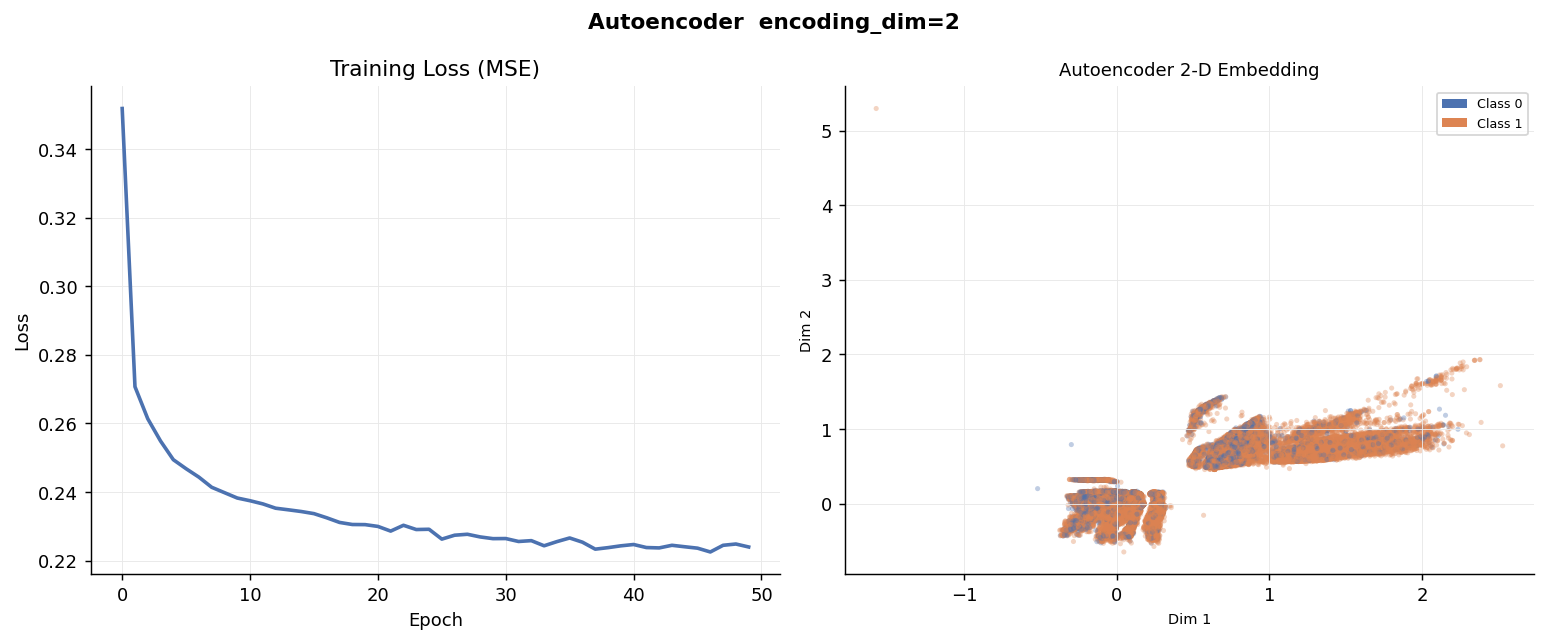

In [46]:
autoencoder_out = run_autoencoder(X_train, y_train_numeric, encoding_dim=2, hidden_dims=[128, 64], epochs=50, batch_size=256, learning_rate=1e-3)

### run ALL methods 

In [48]:
def run_all_methods_comparison(
    X:          pd.DataFrame,
    y:          pd.Series | np.ndarray | None = None,
    n_samples:  int = 5000,
    save_path:  str | None = None,
) -> dict:
    """
    Runs all linear and non-linear methods on the same subsample and
    places all 2-D projections on one comparison figure.
    Use this for the report to pick the best method.

    Methods: PCA, KernelPCA(rbf), FA, UMAP, t-SNE, Isomap, LLE, MDS, TruncSVD
    """
    Xs, _ = _scale(X)
    n_sub  = min(n_samples, len(Xs))
    idx    = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s   = Xs[idx]
    y_s    = np.asarray(y)[idx] if y is not None else None

    method_results = {}

    def _try(name, fn):
        try:
            Z = fn()
            method_results[name] = Z
            print(f"  ✅ {name}")
        except Exception as e:
            method_results[name] = None
            print(f"  ⚠️  {name} failed: {e}")

    print(f"\nRunning all methods on {n_sub:,} samples...")

    _try("PCA",
         lambda: PCA(n_components=2, random_state=42).fit_transform(Xs_s))

    _try("KernelPCA (rbf)",
         lambda: KernelPCA(n_components=2, kernel="rbf",
                           gamma=0.01, random_state=42).fit_transform(Xs_s))

    _try("TruncatedSVD",
         lambda: TruncatedSVD(n_components=2, random_state=42).fit_transform(Xs_s))

    _try("FactorAnalysis",
         lambda: FactorAnalysis(n_components=2, random_state=42).fit_transform(Xs_s))

    _try("t-SNE",
         lambda: TSNE(n_components=2, perplexity=30, init="pca",
                      learning_rate="auto", random_state=42,
                      n_jobs=-1).fit_transform(
             PCA(n_components=min(50, Xs_s.shape[1]),
                 random_state=42).fit_transform(Xs_s)
         ))

    try:
        import umap
        _try("UMAP",
             lambda: umap.UMAP(n_components=2, n_neighbors=15,
                               min_dist=0.1, random_state=42,
                               n_jobs=-1).fit_transform(Xs_s))
    except ImportError:
        method_results["UMAP"] = None
        print("  ⚠️  UMAP not installed")

    _try("Isomap",
         lambda: Isomap(n_components=2, n_neighbors=10).fit_transform(Xs_s))

    _try("LLE",
         lambda: LocallyLinearEmbedding(n_components=2, n_neighbors=10,
                                        method="modified",
                                        random_state=42).fit_transform(Xs_s))

    _try("MDS (metric)",
         lambda: MDS(n_components=2, metric=True,
                     random_state=42, n_jobs=-1).fit_transform(Xs_s))

    # ── Big comparison figure ─────────────────────────────────────────────
    valid = {k: v for k, v in method_results.items() if v is not None}
    n_v   = len(valid)
    n_cols = 3
    n_rows = int(np.ceil(n_v / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(7 * n_cols, 5.5 * n_rows))
    axes = np.array(axes).flatten()
    fig.suptitle("Dimensionality Reduction — All Methods Comparison\n"
                 "(same subsample, same colour coding)",
                 fontsize=13, fontweight="bold")

    for ax, (name, Z) in zip(axes, valid.items()):
        _scatter2d(ax, Z, y_s, name)

    for j in range(len(valid), len(axes)):
        axes[j].set_visible(False)

    fig.tight_layout()
    _save(fig, save_path, "DR_16_all_methods.png")

    # ── Quantitative comparison: silhouette score per method ─────────────
    if y_s is not None:
        print(f"\n  {'Method':25s}  {'Silhouette':>12}  {'Class sep index':>16}")
        print(f"  {'─'*57}")
        for name, Z in valid.items():
            try:
                sil = silhouette_score(Z, y_s, sample_size=min(2000, n_sub))
                # Class separation: mean inter-class distance / mean intra-class dist
                c0 = Z[y_s == 0]
                c1 = Z[y_s == 1]
                if len(c0) > 1 and len(c1) > 1:
                    inter = np.linalg.norm(c0.mean(0) - c1.mean(0))
                    intra = (np.std(c0) + np.std(c1)) / 2
                    sep   = inter / (intra + 1e-9)
                else:
                    sep = 0
                print(f"  {name:25s}  {sil:>12.4f}  {sep:>16.4f}")
            except Exception as e:
                print(f"  {name:25s}  {'error':>12}")

    return method_results



Running all methods on 5,000 samples...
  ✅ PCA
  ✅ KernelPCA (rbf)
  ✅ TruncatedSVD
  ✅ FactorAnalysis
  ✅ t-SNE
  ✅ UMAP
  ✅ Isomap
  ✅ LLE
  ✅ MDS (metric)


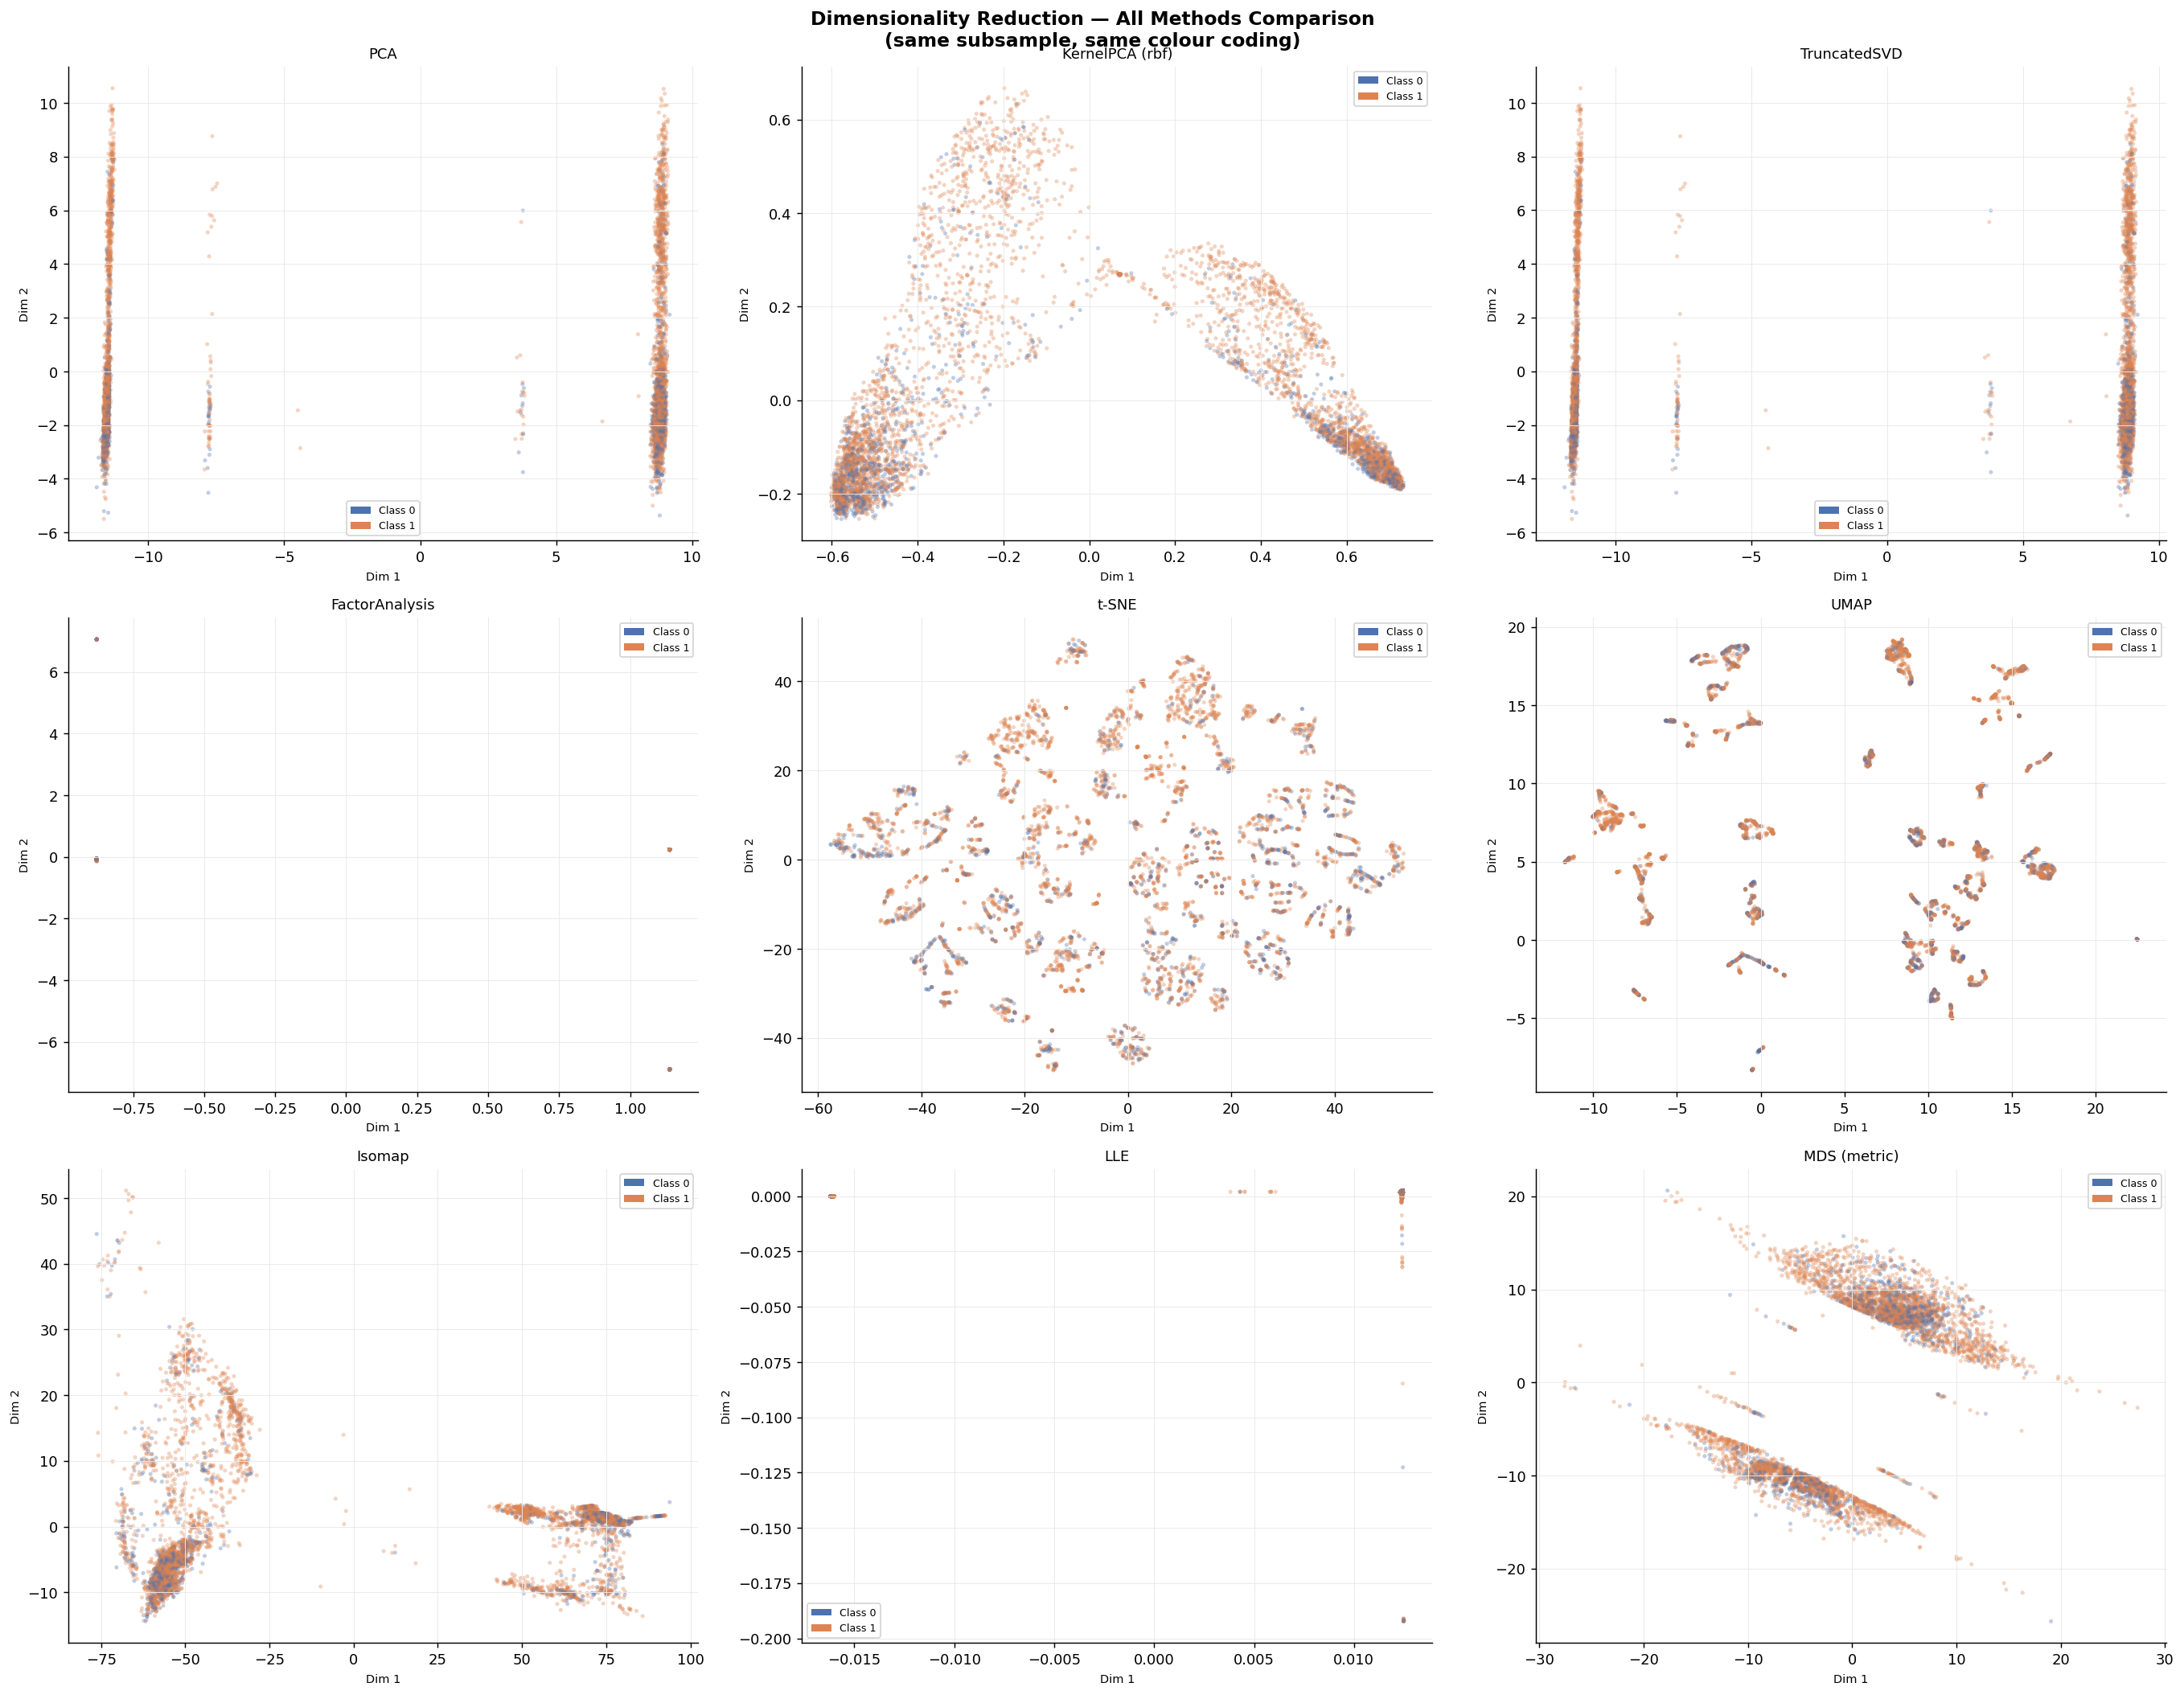


  Method                       Silhouette   Class sep index
  ─────────────────────────────────────────────────────────
  PCA                             -0.0109            0.2222
  KernelPCA (rbf)                  0.0055            0.2722
  TruncatedSVD                    -0.0154            0.2221
  FactorAnalysis                   0.0233            0.0443
  t-SNE                            0.0198            0.2732
  UMAP                             0.0003            0.2340
  Isomap                          -0.0016            0.0759
  LLE                              0.0555            0.0552
  MDS (metric)                    -0.0247            0.0556


In [49]:
comparison_out = run_all_methods_comparison(X_train, y_train_numeric, n_samples=5000)


**RECONSTRUCTION QUALITY**

In [50]:
def reconstruction_quality_report(
    X:          pd.DataFrame,
    k_values:   list[int] = [2, 5, 10, 20, 30, 50],
    save_path:  str | None = None,
) -> pd.DataFrame:
    """
    For each k, computes the reconstruction MSE for PCA, KernelPCA, NMF,
    and Factor Analysis.  Answers: which method retains most information?
    """
    Xs, _ = _scale(X)
    Xs_nn = Xs - Xs.min(axis=0)    # non-negative for NMF

    rows = []
    print(f"\n  {'k':>4}  {'PCA':>10}  {'KernPCA':>10}  {'FA':>10}  {'NMF':>10}")
    print(f"  {'─'*46}")

    for k in k_values:
        k = min(k, Xs.shape[1] - 1)
        r = {"k": k}

        # PCA
        p    = PCA(n_components=k, random_state=42)
        Xr   = p.inverse_transform(p.fit_transform(Xs))
        r["PCA"] = float(np.mean((Xs - Xr) ** 2))

        # Kernel PCA (rbf) — approximate inverse not available, use 1-variance
        kp   = KernelPCA(n_components=k, kernel="rbf", gamma=0.01,
                         fit_inverse_transform=True, random_state=42)
        try:
            Z_kp = kp.fit_transform(Xs[:2000])   # KPCA is O(n²)
            Xr_k = kp.inverse_transform(Z_kp)
            r["KernelPCA"] = float(np.mean((Xs[:2000] - Xr_k) ** 2))
        except Exception:
            r["KernelPCA"] = np.nan

        # Factor Analysis
        fa   = FactorAnalysis(n_components=k, random_state=42)
        Z_fa = fa.fit_transform(Xs)
        # Reconstruct: Z_fa @ components + mean
        Xr_f = Z_fa @ fa.components_ + fa.mean_
        r["FA"] = float(np.mean((Xs - Xr_f) ** 2))

        # NMF
        try:
            nm = NMF(n_components=k, random_state=42, max_iter=300)
            W  = nm.fit_transform(Xs_nn)
            Xr_n = W @ nm.components_
            r["NMF"] = float(np.mean((Xs_nn - Xr_n) ** 2))
        except Exception:
            r["NMF"] = np.nan

        rows.append(r)
        print(f"  {k:>4}  {r['PCA']:>10.5f}  "
              f"{r.get('KernelPCA', float('nan')):>10.5f}  "
              f"{r['FA']:>10.5f}  "
              f"{r.get('NMF', float('nan')):>10.5f}")

    df = pd.DataFrame(rows).set_index("k")

    fig, ax = plt.subplots(figsize=(9, 5))
    for col in df.columns:
        ax.plot(df.index, df[col], "o-", label=col, linewidth=2, markersize=5)
    ax.set_title("Reconstruction MSE vs n_components\n"
                 "(lower = better; where curves flatten = diminishing returns)",
                 fontsize=11, fontweight="bold")
    ax.set_xlabel("n_components (k)")
    ax.set_ylabel("Reconstruction MSE")
    ax.legend()
    fig.tight_layout()
    _save(fig, save_path, "DR_17_reconstruction_quality.png")

    return df



     k         PCA     KernPCA          FA         NMF
  ──────────────────────────────────────────────
     2     0.26148     0.29501     0.31776     0.32197
     5     0.17252     0.24784     0.22483     0.21628
    10     0.11637     0.21529     0.18332     0.14819
    20     0.04982     0.19272     0.13235     0.07591
    30     0.01114     0.18324     0.11723     0.04306
    50     0.00003     0.17682     0.09144     0.00238


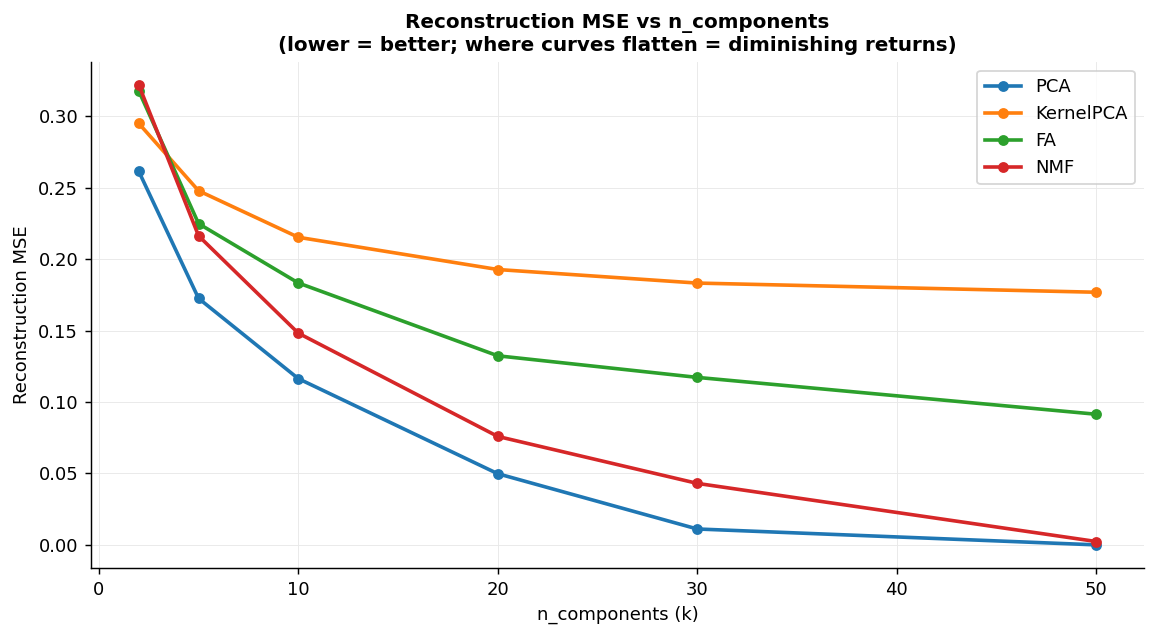

In [51]:
reconstruction_report = reconstruction_quality_report(X_train, k_values=[2, 5, 10, 20, 30, 50])


**run everything in sequence**

In [ ]:






def run_full_dr_report(
    X:          pd.DataFrame,
    y:          pd.Series | np.ndarray | None = None,
    save_path:  str   = "./dr_report",
    n_samples_fast: int = 5000,
    n_samples_slow: int = 3000,
):
    """
    Runs the complete Q3 dimensionality reduction analysis.
    Saves all plots to save_path.


    Parameters
    ----------
    X           : feature DataFrame (numerical columns only used)
    y           : target array for colour coding
    save_path   : directory for all output plots
    n_samples_fast : samples for fast methods (PCA, FA, UMAP)
    n_samples_slow : samples for slow methods (t-SNE, LLE, Isomap, MDS)
    """
    print(f"\n{'═'*65}")
    print("  Q3 — FULL DIMENSIONALITY REDUCTION REPORT")
    print(f"{'═'*65}")

    # Step 1: How many dimensions?
    print("\n[1/7] How many dimensions are needed?")
    summary = how_many_dimensions(X, y, save_path=save_path)

    # Step 2: PCA full
    print("\n[2/7] Full PCA analysis...")
    pca_out = run_pca_full(X, y, n_components=30, save_path=save_path)

    # Step 3: Kernel PCA
    print("\n[3/7] Kernel PCA...")
    kpca_out = run_kernel_pca(X, y, save_path=save_path)

    # Step 4: Factor Analysis
    print("\n[4/7] Factor Analysis...")
    fa_out = run_factor_analysis(X, y, save_path=save_path)

    # Step 5: t-SNE
    print(f"\n[5/7] t-SNE (n={n_samples_slow:,})...")
    tsne_out = run_tsne(X, y, n_samples=n_samples_slow, save_path=save_path)

    # Step 6: UMAP
    print(f"\n[6/7] UMAP (n={n_samples_fast:,})...")
    umap_out = run_umap(X, y, n_samples=n_samples_fast, save_path=save_path)

    # Step 7: All methods comparison
    print(f"\n[7/7] All-methods comparison (n={n_samples_fast:,})...")
    all_out = run_all_methods_comparison(X, y,
                                         n_samples=n_samples_fast,
                                         save_path=save_path)

    # Reconstruction quality
    print("\n[+]  Reconstruction quality report...")
    recon = reconstruction_quality_report(X, save_path=save_path)

    print(f"\n{'═'*65}")
    print(f"  ✅  All DR plots saved to: {save_path}")
    print(f"{'═'*65}")

    return {
        "summary":    summary,
        "pca":        pca_out,
        "kpca":       kpca_out,
        "fa":         fa_out,
        "tsne":       tsne_out,
        "umap":       umap_out,
        "all_methods":all_out,
        "recon":      recon,
    }


# ─────────────────────────────────────────────────────────────────────────────
# USAGE GUIDE
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("""

# ONE-CALL complete report:
results = run_full_dr_report(
    X          = X_train,      # your feature DataFrame
    y          = y_train,      # target Series for colour coding
    save_path  = "./dr_report",
)

   the recommended n_components for downstream tasks.
""")

In [52]:
"""
Q3 — Additional Dimensionality Reduction Functions
====================================================
Supplements the main dimensionality_reduction.py with 4 high-value analyses:

1. run_correlation_heatmap        → Show WHY PCA works (r>0.97 clusters)
2. run_pca_vs_raw_classifier      → Prove DR helps (or doesn't) downstream
3. run_uniform_loading_diagnosis  → Diagnose the suspicious PC1 equal-loading
4. run_autoencoder_vs_pca         → Compare neural vs linear reconstruction

Usage
-----
    from dimensionality_reduction_extra import (
        run_correlation_heatmap,
        run_pca_vs_raw_classifier,
        run_uniform_loading_diagnosis,
        run_autoencoder_vs_pca,
        run_all_extras,
    )

    # Run everything:
    run_all_extras(X_train, y_train, save_path="./dr_extra")

    # Or individually:
    run_correlation_heatmap(X_train, save_path="./dr_extra")
    run_pca_vs_raw_classifier(X_train, y_train, save_path="./dr_extra")
    run_uniform_loading_diagnosis(X_train, save_path="./dr_extra")
"""

from __future__ import annotations
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

from sklearn.preprocessing   import StandardScaler
from sklearn.decomposition   import PCA
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics         import roc_auc_score, f1_score
from sklearn.neural_network  import MLPClassifier

warnings.filterwarnings("ignore")

_C0, _C1 = "#4C72B0", "#DD8452"

plt.rcParams.update({
    "figure.dpi":        130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#E8E8E8",
    "grid.linewidth":    0.5,
})


# ─── helpers ─────────────────────────────────────────────────────────────────
def _scale(X: pd.DataFrame) -> tuple[np.ndarray, list[str]]:
    num_cols = X.select_dtypes(include=np.number).columns
    Xn = X[num_cols].fillna(X[num_cols].median())
    Xs = StandardScaler().fit_transform(Xn)
    return Xs, num_cols.tolist()


def _save(fig, save_path: str | None, name: str):
    if save_path:
        os.makedirs(save_path, exist_ok=True)
        fig.savefig(os.path.join(save_path, name), bbox_inches="tight", dpi=150)
    plt.show()
    plt.close(fig)


# ─────────────────────────────────────────────────────────────────────────────
# 1.  CORRELATION HEATMAP — WHY PCA WORKS SO WELL
# ─────────────────────────────────────────────────────────────────────────────
def run_correlation_heatmap(
    X:          pd.DataFrame,
    top_n:      int  = 40,
    threshold:  float = 0.85,
    save_path:  str | None = None,
) -> pd.DataFrame:
    """
    Computes and visualises feature correlations to explain WHY the data
    is so compressible (80% variance in just 4 PCA components).

    Plots
    -----
    1. Heatmap of the top_n most-correlated features (clustered)
    2. Distribution of all pairwise correlation coefficients
    3. Bar chart: how many features each feature is highly correlated with

    Returns
    -------
    DataFrame of highly correlated pairs (|r| >= threshold).
    """
    num_cols = X.select_dtypes(include=np.number).columns
    Xn = X[num_cols].fillna(X[num_cols].median())
    corr = Xn.corr()

    # --- find highly correlated pairs ---
    pairs = []
    cols = corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            r = corr.iloc[i, j]
            if abs(r) >= threshold:
                pairs.append({"feature_A": cols[i],
                               "feature_B": cols[j],
                               "pearson_r": round(r, 4)})
    pairs_df = pd.DataFrame(pairs).sort_values("pearson_r",
                                                ascending=False,
                                                key=abs)

    # --- select top_n most interconnected features ---
    if len(pairs_df) > 0:
        involved = pd.concat([pairs_df["feature_A"],
                               pairs_df["feature_B"]]).value_counts()
        top_feats = involved.head(top_n).index.tolist()
    else:
        top_feats = cols[:top_n]

    sub_corr = corr.loc[top_feats, top_feats]

    # --- plots ---
    fig = plt.figure(figsize=(20, 14))
    gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)
    fig.suptitle(
        f"Feature Correlation Structure — Explaining Why PCA Compresses So Well\n"
        f"({len(pairs_df):,} pairs with |r| ≥ {threshold}  out of "
        f"{len(cols) * (len(cols)-1) // 2:,} total pairs)",
        fontsize=13, fontweight="bold",
    )

    # Plot 1: clustered heatmap
    ax0 = fig.add_subplot(gs[:, :2])
    mask = np.zeros_like(sub_corr, dtype=bool)
    np.fill_diagonal(mask, True)
    sns.heatmap(
        sub_corr, mask=mask, cmap="RdBu_r", center=0,
        vmin=-1, vmax=1, linewidths=0.2, ax=ax0,
        xticklabels=True, yticklabels=True,
        cbar_kws={"label": "Pearson r"},
    )
    ax0.set_title(
        f"Correlation Heatmap — Top {top_n} Most Inter-Correlated Features\n"
        "(clustered; red = strong positive, blue = strong negative)",
        fontsize=11,
    )
    ax0.tick_params(axis="x", rotation=90, labelsize=6)
    ax0.tick_params(axis="y", rotation=0,  labelsize=6)

    # Plot 2: distribution of all pairwise correlations
    ax1 = fig.add_subplot(gs[0, 2])
    flat = corr.values[np.triu_indices_from(corr.values, k=1)]
    ax1.hist(flat, bins=80, color=_C0, alpha=0.8, edgecolor="none")
    ax1.axvline(threshold,  color="red",    linestyle="--",
                label=f"|r| = {threshold}")
    ax1.axvline(-threshold, color="red",    linestyle="--")
    ax1.axvline(0, color="black", linewidth=0.8)
    ax1.set_title("Distribution of All Pairwise Correlations")
    ax1.set_xlabel("Pearson r")
    ax1.set_ylabel("Count")
    ax1.legend(fontsize=8)

    # Plot 3: features with most high-correlation partners
    ax2 = fig.add_subplot(gs[1, 2])
    if len(pairs_df) > 0:
        involved.head(20).sort_values().plot(
            kind="barh", ax=ax2, color=_C1, alpha=0.85,
        )
        ax2.set_title(f"Features with Most Partners (|r| ≥ {threshold})")
        ax2.set_xlabel("Number of highly-correlated partners")
    else:
        ax2.set_title("No highly-correlated pairs found")

    _save(fig, save_path, "DR_extra_01_correlation_heatmap.png")

    # --- print summary ---
    print(f"\n{'═'*60}")
    print("  Feature Correlation Summary")
    print(f"{'═'*60}")
    print(f"  Total features           : {len(cols)}")
    print(f"  Total pairs              : {len(cols) * (len(cols)-1) // 2:,}")
    print(f"  Pairs with |r| ≥ {threshold}  : {len(pairs_df):,}")
    if len(pairs_df) > 0:
        print(f"\n  Top 15 most correlated pairs:")
        print(pairs_df.head(15).to_string(index=False))
    print(f"{'═'*60}")
    print("\n  ➜  WHY THIS MATTERS FOR PCA:")
    print(f"     {len(pairs_df):,} highly-correlated pairs means the 150 features")
    print("     carry massively redundant information.")
    print("     PCA exploits this: correlated features collapse into shared PCs,")
    print("     which is why 4 components capture 80% of all variance.")

    return pairs_df


# ─────────────────────────────────────────────────────────────────────────────
# 2.  CLASSIFIER: RAW vs PCA-REDUCED vs OTHER REDUCTIONS
# ─────────────────────────────────────────────────────────────────────────────
def run_pca_vs_raw_classifier(
    X:            pd.DataFrame,
    y:            pd.Series | np.ndarray,
    n_components_list: list[int] = [4, 13, 15, 21, 31, 50],
    cv_folds:     int  = 5,
    n_samples:    int  = 20000,
    save_path:    str | None = None,
) -> pd.DataFrame:
    """
    The most important validation of DR: does reducing dimensions actually
    help classifiers? Compares:
      - Raw features (150 dims, scaled)
      - PCA at various n_components (4 / 13 / 15 / 21 / 31 / 50)

    Classifiers tested:
      - Logistic Regression (linear, fast)
      - Random Forest       (non-linear, feature-importance)
      - MLP                 (neural, handles non-linearity)

    Metrics: ROC-AUC, F1 (macro), fit time

    Returns
    -------
    DataFrame with all results.
    """
    Xs, _ = _scale(X)
    y_arr = np.asarray(y)

    # subsample for speed
    n_sub = min(n_samples, len(Xs))
    idx   = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s  = Xs[idx]
    y_s   = y_arr[idx]

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)

    classifiers = {
        "LogisticReg": LogisticRegression(
            max_iter=300, random_state=42, C=1.0, solver="lbfgs",
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1, max_depth=8,
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(64, 32), max_iter=100,
            random_state=42, early_stopping=True,
        ),
    }

    rows = []

    # --- Raw baseline ---
    print(f"\nRunning classifiers on {n_sub:,} samples, {cv_folds}-fold CV...")
    print(f"{'─'*65}")

    for clf_name, clf in classifiers.items():
        print(f"  [Raw 150 dims]  {clf_name}...", end=" ", flush=True)
        try:
            res = cross_validate(
                clf, Xs_s, y_s, cv=cv,
                scoring=["roc_auc", "f1_macro"],
                return_train_score=False, n_jobs=-1,
            )
            rows.append({
                "configuration": "Raw (150 dims)",
                "n_components":  150,
                "classifier":    clf_name,
                "roc_auc":       round(res["test_roc_auc"].mean(),    4),
                "roc_auc_std":   round(res["test_roc_auc"].std(),     4),
                "f1_macro":      round(res["test_f1_macro"].mean(),   4),
                "fit_time_s":    round(res["fit_time"].mean(),        2),
            })
            print(f"AUC={rows[-1]['roc_auc']:.4f}")
        except Exception as e:
            print(f"FAILED: {e}")

    # --- PCA variants ---
    for k in n_components_list:
        k = min(k, Xs_s.shape[1])
        pca   = PCA(n_components=k, random_state=42)
        Xk    = pca.fit_transform(Xs_s)
        var_k = pca.explained_variance_ratio_.sum()

        for clf_name, clf in classifiers.items():
            label = f"PCA-{k} ({var_k:.0%} var)"
            print(f"  [{label}]  {clf_name}...", end=" ", flush=True)
            try:
                res = cross_validate(
                    clf, Xk, y_s, cv=cv,
                    scoring=["roc_auc", "f1_macro"],
                    return_train_score=False, n_jobs=-1,
                )
                rows.append({
                    "configuration": label,
                    "n_components":  k,
                    "classifier":    clf_name,
                    "roc_auc":       round(res["test_roc_auc"].mean(),   4),
                    "roc_auc_std":   round(res["test_roc_auc"].std(),    4),
                    "f1_macro":      round(res["test_f1_macro"].mean(),  4),
                    "fit_time_s":    round(res["fit_time"].mean(),       2),
                })
                print(f"AUC={rows[-1]['roc_auc']:.4f}")
            except Exception as e:
                print(f"FAILED: {e}")

    results = pd.DataFrame(rows)

    # --- plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f"Classifier Performance: Raw Features vs PCA Reduction\n"
        f"(n={n_sub:,}, {cv_folds}-fold stratified CV)",
        fontsize=13, fontweight="bold",
    )

    configs_ordered = (
        ["Raw (150 dims)"] +
        [f"PCA-{k} ({PCA(n_components=min(k, Xs_s.shape[1]), random_state=42).fit(Xs_s).explained_variance_ratio_.sum():.0%} var)"
         for k in n_components_list]
    )

    colors_clf = {"LogisticReg": "#4C72B0",
                  "RandomForest": "#DD8452",
                  "MLP": "#55A868"}

    for ax, clf_name in zip(axes, classifiers.keys()):
        sub = results[results["classifier"] == clf_name].copy()
        sub = sub.set_index("configuration").reindex(configs_ordered).reset_index()

        bars = ax.bar(
            range(len(sub)), sub["roc_auc"],
            color=[colors_clf[clf_name]] * len(sub),
            alpha=0.85, width=0.6,
        )
        # error bars
        ax.errorbar(
            range(len(sub)), sub["roc_auc"],
            yerr=sub["roc_auc_std"],
            fmt="none", color="black", capsize=4, linewidth=1.2,
        )
        # highlight raw bar differently
        if len(bars) > 0:
            bars[0].set_edgecolor("black")
            bars[0].set_linewidth(2)

        ax.set_title(f"{clf_name}\nROC-AUC (higher = better)", fontsize=10)
        ax.set_xticks(range(len(sub)))
        ax.set_xticklabels(sub["configuration"], rotation=45, ha="right", fontsize=7)
        ax.set_ylabel("ROC-AUC")
        ymin = max(0, sub["roc_auc"].min() - 0.05)
        ymax = min(1, sub["roc_auc"].max() + 0.05)
        ax.set_ylim(ymin, ymax)

        # annotate bars
        for i, (_, row) in enumerate(sub.iterrows()):
            if not pd.isna(row["roc_auc"]):
                ax.text(i, row["roc_auc"] + sub["roc_auc_std"].max() * 0.5 + 0.002,
                        f"{row['roc_auc']:.3f}", ha="center", va="bottom",
                        fontsize=7, fontweight="bold")

    fig.tight_layout()
    _save(fig, save_path, "DR_extra_02_classifier_comparison.png")

    # --- print summary table ---
    print(f"\n{'═'*80}")
    print("  Classification Results Summary")
    print(f"{'═'*80}")
    pivot = results.pivot_table(
        index="configuration", columns="classifier",
        values="roc_auc", aggfunc="first",
    ).reindex(configs_ordered)
    print(pivot.round(4).to_string())

    # Best config per classifier
    print(f"\n  Best configuration per classifier (by ROC-AUC):")
    for clf_name in classifiers:
        sub = results[results["classifier"] == clf_name]
        best = sub.loc[sub["roc_auc"].idxmax()]
        raw  = sub[sub["configuration"] == "Raw (150 dims)"]["roc_auc"].values
        delta = best["roc_auc"] - (raw[0] if len(raw) > 0 else 0)
        sign  = "+" if delta >= 0 else ""
        print(f"    {clf_name:15s}: {best['configuration']:30s}  "
              f"AUC={best['roc_auc']:.4f}  "
              f"(Δ vs raw: {sign}{delta:.4f})")
    print(f"{'═'*80}")

    return results


# ─────────────────────────────────────────────────────────────────────────────
# 3.  UNIFORM LOADING DIAGNOSIS — WHY PC1 LOADS EQUALLY ON ~100 FEATURES
# ─────────────────────────────────────────────────────────────────────────────
def run_uniform_loading_diagnosis(
    X:          pd.DataFrame,
    save_path:  str | None = None,
) -> dict:
    """
    PC1 explains 66.95% and loads at exactly +0.0999 on many features.
    This function diagnoses WHY:

    1. Identifies feature groups that are perfectly correlated (r ~ 1.0)
    2. Shows the "effective number of unique features" after deduplication
    3. Shows correlation cluster membership for each feature group
    4. Demonstrates that PCA of perfectly-correlated features
       collapses them into one component with equal loadings

    Returns
    -------
    dict with {groups, effective_n_features, loading_entropy_per_pc}
    """
    Xs, feat_names = _scale(X)
    pca = PCA(n_components=min(30, len(feat_names)), random_state=42)
    Z   = pca.fit_transform(Xs)

    loadings = pd.DataFrame(
        pca.components_.T,
        index=feat_names,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    )

    # --- 1. loading entropy per PC (uniform = low entropy = suspicious) ---
    # High entropy = loadings are spread out (diverse)
    # Low entropy  = one feature dominates (focused)
    # EQUAL loadings = maximum entropy (uniform distribution)
    from scipy.stats import entropy as scipy_entropy
    ent_list = []
    for pc in loadings.columns:
        w = np.abs(loadings[pc].values)
        w = w / w.sum()
        ent_list.append(scipy_entropy(w))

    ent_series = pd.Series(ent_list, index=loadings.columns)

    # --- 2. find perfectly-correlated feature groups ---
    num_cols = X.select_dtypes(include=np.number).columns
    Xn = X[num_cols].fillna(X[num_cols].median())
    corr_mat = Xn.corr().abs()

    # Union-Find to group features with r >= 0.99
    parent = {c: c for c in corr_mat.columns}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(x, y):
        parent[find(x)] = find(y)

    for i, ci in enumerate(corr_mat.columns):
        for j, cj in enumerate(corr_mat.columns):
            if i < j and corr_mat.loc[ci, cj] >= 0.99:
                union(ci, cj)

    groups: dict[str, list[str]] = {}
    for col in corr_mat.columns:
        root = find(col)
        groups.setdefault(root, []).append(col)

    # only keep groups with more than 1 member
    clusters = {k: v for k, v in groups.items() if len(v) > 1}
    singletons = sum(1 for v in groups.values() if len(v) == 1)
    effective_n = len(clusters) + singletons

    # --- plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        "PC1 Uniform-Loading Diagnosis\n"
        "Understanding why PC1 loads at exactly +0.0999 across ~100 features",
        fontsize=12, fontweight="bold",
    )

    # Plot 1: loading entropy per PC
    ax = axes[0]
    ax.bar(range(1, len(ent_series)+1), ent_series.values,
           color=_C0, alpha=0.8)
    ax.axhline(np.log(len(feat_names)), color="red", linestyle="--",
               label=f"Max entropy\n(perfect uniform, n={len(feat_names)})")
    ax.set_title("Loading Entropy per PC\n"
                 "(high = uniform loading = equal contribution\n"
                 "low = one feature dominates)")
    ax.set_xlabel("PC")
    ax.set_ylabel("Shannon entropy of |loadings|")
    ax.legend(fontsize=7)

    # Plot 2: distribution of PC1 absolute loadings
    ax = axes[1]
    pc1_abs = np.abs(loadings["PC1"].values)
    ax.hist(pc1_abs, bins=40, color=_C1, alpha=0.85, edgecolor="none")
    ax.axvline(1 / np.sqrt(len(feat_names)), color="red", linestyle="--",
               label=f"1/√{len(feat_names)} = {1/np.sqrt(len(feat_names)):.4f}\n"
                     "(expected for uniform loading)")
    ax.set_title("PC1 Absolute Loading Distribution\n"
                 "Peak near 0.0999 = uniform loading across ~100 features")
    ax.set_xlabel("|Loading|")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

    # Plot 3: cluster sizes
    ax = axes[2]
    cluster_sizes = sorted([len(v) for v in clusters.values()], reverse=True)
    ax.bar(range(len(cluster_sizes)), cluster_sizes,
           color=_C0, alpha=0.8)
    ax.set_title(f"Correlation Cluster Sizes (r ≥ 0.99)\n"
                 f"{len(clusters)} clusters + {singletons} singletons\n"
                 f"= {effective_n} effective unique features (from {len(feat_names)})")
    ax.set_xlabel("Cluster rank")
    ax.set_ylabel("Number of features in cluster")

    fig.tight_layout()
    _save(fig, save_path, "DR_extra_03_uniform_loading_diagnosis.png")

    # --- print summary ---
    print(f"\n{'═'*65}")
    print("  PC1 Uniform-Loading Diagnosis")
    print(f"{'═'*65}")
    print(f"  Original features     : {len(feat_names)}")
    print(f"  Correlation clusters  : {len(clusters)}  (groups with r ≥ 0.99)")
    print(f"  Singleton features    : {singletons}")
    print(f"  Effective unique dims : {effective_n}  (true information content)")
    print(f"\n  PC1 entropy           : {ent_series['PC1']:.4f}")
    print(f"  Max possible entropy  : {np.log(len(feat_names)):.4f}  (uniform)")
    print(f"  Ratio                 : {ent_series['PC1'] / np.log(len(feat_names)):.3f}")
    print(f"\n  → PC1 entropy ratio near 1.0 confirms it is loading")
    print(f"    nearly uniformly across all features.")
    print(f"    This happens because {len(feat_names) - singletons} features are")
    print(f"    strongly inter-correlated and share a common direction.")
    if clusters:
        print(f"\n  Top 5 largest correlation clusters (r ≥ 0.99):")
        for root, members in sorted(clusters.items(),
                                    key=lambda x: -len(x[1]))[:5]:
            print(f"    [{len(members)} members]: {', '.join(members[:5])}"
                  f"{'...' if len(members) > 5 else ''}")
    print(f"{'═'*65}")

    return {
        "groups":             clusters,
        "effective_n_features": effective_n,
        "loading_entropy":    ent_series,
    }


# ─────────────────────────────────────────────────────────────────────────────
# 4.  AUTOENCODER vs PCA — RECONSTRUCTION QUALITY
# ─────────────────────────────────────────────────────────────────────────────
def run_autoencoder_vs_pca(
    X:            pd.DataFrame,
    encoding_dims: list[int] = [2, 5, 10, 21],
    epochs:        int   = 30,
    n_samples:     int   = 15000,
    save_path:     str | None = None,
) -> pd.DataFrame:
    """
    Compares reconstruction MSE of PCA vs a shallow Autoencoder at the same
    encoding dimensions. Answers: is a non-linear autoencoder worth the cost
    over linear PCA for this dataset?

    Uses sklearn MLPRegressor as a portable autoencoder substitute
    (no PyTorch required).

    Returns
    -------
    DataFrame with columns [encoding_dim, pca_mse, ae_mse, ae_vs_pca_ratio]
    """
    Xs, _ = _scale(X)
    n_sub = min(n_samples, len(Xs))
    idx   = np.random.RandomState(42).choice(len(Xs), n_sub, replace=False)
    Xs_s  = Xs[idx]

    rows = []
    print(f"\nAutoencoder vs PCA comparison on {n_sub:,} samples...")
    print(f"{'─'*55}")

    for k in encoding_dims:
        k = min(k, Xs_s.shape[1] - 1)

        # PCA MSE
        pca  = PCA(n_components=k, random_state=42)
        Xr   = pca.inverse_transform(pca.fit_transform(Xs_s))
        pca_mse = float(np.mean((Xs_s - Xr) ** 2))

        # Autoencoder MSE via sklearn MLP bottleneck
        # Architecture: input → [128,64] → k → [64,128] → output
        h1, h2 = min(128, Xs_s.shape[1]), min(64, Xs_s.shape[1])
        ae = MLPClassifier.__new__(MLPClassifier)  # just need the class name
        from sklearn.neural_network import MLPRegressor
        ae = MLPRegressor(
            hidden_layer_sizes=(h1, h2, k, h2, h1),
            activation="relu",
            max_iter=epochs,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=5,
            verbose=False,
        )
        ae.fit(Xs_s, Xs_s)
        Xr_ae = ae.predict(Xs_s)
        ae_mse = float(np.mean((Xs_s - Xr_ae) ** 2))
        ratio  = ae_mse / (pca_mse + 1e-10)

        rows.append({
            "encoding_dim":    k,
            "pca_mse":         round(pca_mse,  5),
            "ae_mse":          round(ae_mse,   5),
            "ae_vs_pca_ratio": round(ratio,    3),
            "pca_var_explained": round(
                float(pca.explained_variance_ratio_.sum()), 4),
        })
        print(f"  k={k:3d}  PCA MSE={pca_mse:.5f}  "
              f"AE MSE={ae_mse:.5f}  ratio={ratio:.3f}")

    results = pd.DataFrame(rows)

    # --- plot ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        "Autoencoder vs PCA: Reconstruction MSE\n"
        "(lower = better; ratio < 1.0 = AE beats PCA)",
        fontsize=12, fontweight="bold",
    )

    ax = axes[0]
    x = np.arange(len(results))
    w = 0.35
    ax.bar(x - w/2, results["pca_mse"], width=w, label="PCA", color=_C0, alpha=0.85)
    ax.bar(x + w/2, results["ae_mse"],  width=w, label="Autoencoder",
           color=_C1, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels([f"k={k}" for k in results["encoding_dim"]])
    ax.set_title("Reconstruction MSE at Each Encoding Dimension")
    ax.set_ylabel("MSE")
    ax.legend()

    ax = axes[1]
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1,
               label="ratio=1 (equal performance)")
    ax.plot(results["encoding_dim"], results["ae_vs_pca_ratio"],
            "o-", color=_C1, linewidth=2, markersize=8, label="AE/PCA ratio")
    ax.fill_between(results["encoding_dim"], 1, results["ae_vs_pca_ratio"],
                    where=results["ae_vs_pca_ratio"] < 1,
                    alpha=0.2, color="green", label="AE wins")
    ax.fill_between(results["encoding_dim"], 1, results["ae_vs_pca_ratio"],
                    where=results["ae_vs_pca_ratio"] >= 1,
                    alpha=0.2, color="red", label="PCA wins")
    ax.set_title("AE MSE / PCA MSE Ratio\n(< 1.0: Autoencoder is better)")
    ax.set_xlabel("Encoding dimension (k)")
    ax.set_ylabel("MSE ratio (AE / PCA)")
    ax.legend(fontsize=8)

    fig.tight_layout()
    _save(fig, save_path, "DR_extra_04_autoencoder_vs_pca.png")

    # print interpretation
    pca_wins = (results["ae_vs_pca_ratio"] >= 1).sum()
    ae_wins  = (results["ae_vs_pca_ratio"] <  1).sum()
    print(f"\n  PCA wins at {pca_wins}/{len(results)} encoding dimensions")
    print(f"  AE  wins at {ae_wins}/{len(results)} encoding dimensions")
    if pca_wins >= ae_wins:
        print("  → PCA is recommended: linear reduction is sufficient.")
        print("    The data does not have strong non-linear structure")
        print("    that an autoencoder can exploit over PCA.")
    else:
        print("  → Autoencoder is recommended: non-linear structure exists.")

    return results


# ─────────────────────────────────────────────────────────────────────────────
# MASTER FUNCTION — RUN ALL EXTRAS
# ─────────────────────────────────────────────────────────────────────────────
def run_all_extras(
    X:         pd.DataFrame,
    y:         pd.Series | np.ndarray | None = None,
    save_path: str = "./dr_extra",
) -> dict:
    """
    Runs all 4 supplementary analyses in sequence.

    Parameters
    ----------
    X          : feature DataFrame
    y          : target Series (required for classifier comparison)
    save_path  : directory for output plots

    Returns
    -------
    dict with all results
    """
    print(f"\n{'═'*65}")
    print("  Q3 EXTRA — Supplementary DR Analyses")
    print(f"{'═'*65}")

    # 1. Correlation heatmap
    print("\n[1/4] Feature correlation structure...")
    corr_pairs = run_correlation_heatmap(X, save_path=save_path)

    # 2. Classifier comparison (only if y provided)
    clf_results = None
    if y is not None:
        print("\n[2/4] Classifier: raw vs PCA-reduced...")
        clf_results = run_pca_vs_raw_classifier(X, y, save_path=save_path)
    else:
        print("\n[2/4] Skipping classifier comparison (no y provided)")

    # 3. Uniform loading diagnosis
    print("\n[3/4] PC1 uniform-loading diagnosis...")
    diag = run_uniform_loading_diagnosis(X, save_path=save_path)

    # 4. Autoencoder vs PCA
    print("\n[4/4] Autoencoder vs PCA reconstruction...")
    ae_results = run_autoencoder_vs_pca(X, save_path=save_path)

    print(f"\n{'═'*65}")
    print(f"  ✅  All extra analyses saved to: {save_path}")
    print(f"{'═'*65}")

    return {
        "correlation_pairs": corr_pairs,
        "classifier_results": clf_results,
        "loading_diagnosis":  diag,
        "ae_vs_pca":          ae_results,
    }


# ─────────────────────────────────────────────────────────────────────────────
# USAGE GUIDE
# ─────────────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    print("""
USAGE — Q3 Extra Dimensionality Reduction Analyses
════════════════════════════════════════════════════════════════

from dimensionality_reduction_extra import run_all_extras

# ONE-CALL complete extra report:
results = run_all_extras(
    X          = X_train,   # your feature DataFrame
    y          = y_train,   # target Series
    save_path  = "./dr_extra",
)

# Individual functions:
from dimensionality_reduction_extra import (
    run_correlation_heatmap,        # WHY PCA compresses so well
    run_pca_vs_raw_classifier,      # DOES DR help classifiers?
    run_uniform_loading_diagnosis,  # WHY PC1 loads equally on ~100 features
    run_autoencoder_vs_pca,         # IS non-linear reduction worth it?
)

corr_pairs  = run_correlation_heatmap(X_train)
clf_results = run_pca_vs_raw_classifier(X_train, y_train)
diag        = run_uniform_loading_diagnosis(X_train)
ae_results  = run_autoencoder_vs_pca(X_train)

WHAT EACH FUNCTION PROVES
─────────────────────────────────────────────────────────────────
1. run_correlation_heatmap
   → Shows the r>0.97 clusters that make 150 features redundant.
   → Justifies why PCA collapses them: correlated = shared direction.

2. run_pca_vs_raw_classifier
   → THE key validation: does reducing from 150→21 dims hurt AUC?
   → If AUC is similar or better → DR is safe to use before modelling.
   → If AUC drops significantly → keep raw features for classification.

3. run_uniform_loading_diagnosis
   → PC1 loads at +0.0999 on many features because they are all
     nearly perfectly correlated → they share one common direction.
   → Computes "effective unique features" after deduplication.

4. run_autoencoder_vs_pca
   → Tests whether a non-linear bottleneck beats PCA reconstruction.
   → If PCA wins: the data is linearly compressible → use PCA.
   → If AE wins: there is non-linear structure → consider autoencoders.
""")


USAGE — Q3 Extra Dimensionality Reduction Analyses
════════════════════════════════════════════════════════════════

from dimensionality_reduction_extra import run_all_extras

# ONE-CALL complete extra report:
results = run_all_extras(
    X          = X_train,   # your feature DataFrame
    y          = y_train,   # target Series
    save_path  = "./dr_extra",
)

# Individual functions:
from dimensionality_reduction_extra import (
    run_correlation_heatmap,        # WHY PCA compresses so well
    run_pca_vs_raw_classifier,      # DOES DR help classifiers?
    run_uniform_loading_diagnosis,  # WHY PC1 loads equally on ~100 features
    run_autoencoder_vs_pca,         # IS non-linear reduction worth it?
)

corr_pairs  = run_correlation_heatmap(X_train)
clf_results = run_pca_vs_raw_classifier(X_train, y_train)
diag        = run_uniform_loading_diagnosis(X_train)
ae_results  = run_autoencoder_vs_pca(X_train)

WHAT EACH FUNCTION PROVES
───────────────────────────────────────────────────


═════════════════════════════════════════════════════════════════
  Q3 EXTRA — Supplementary DR Analyses
═════════════════════════════════════════════════════════════════

[1/4] Feature correlation structure...


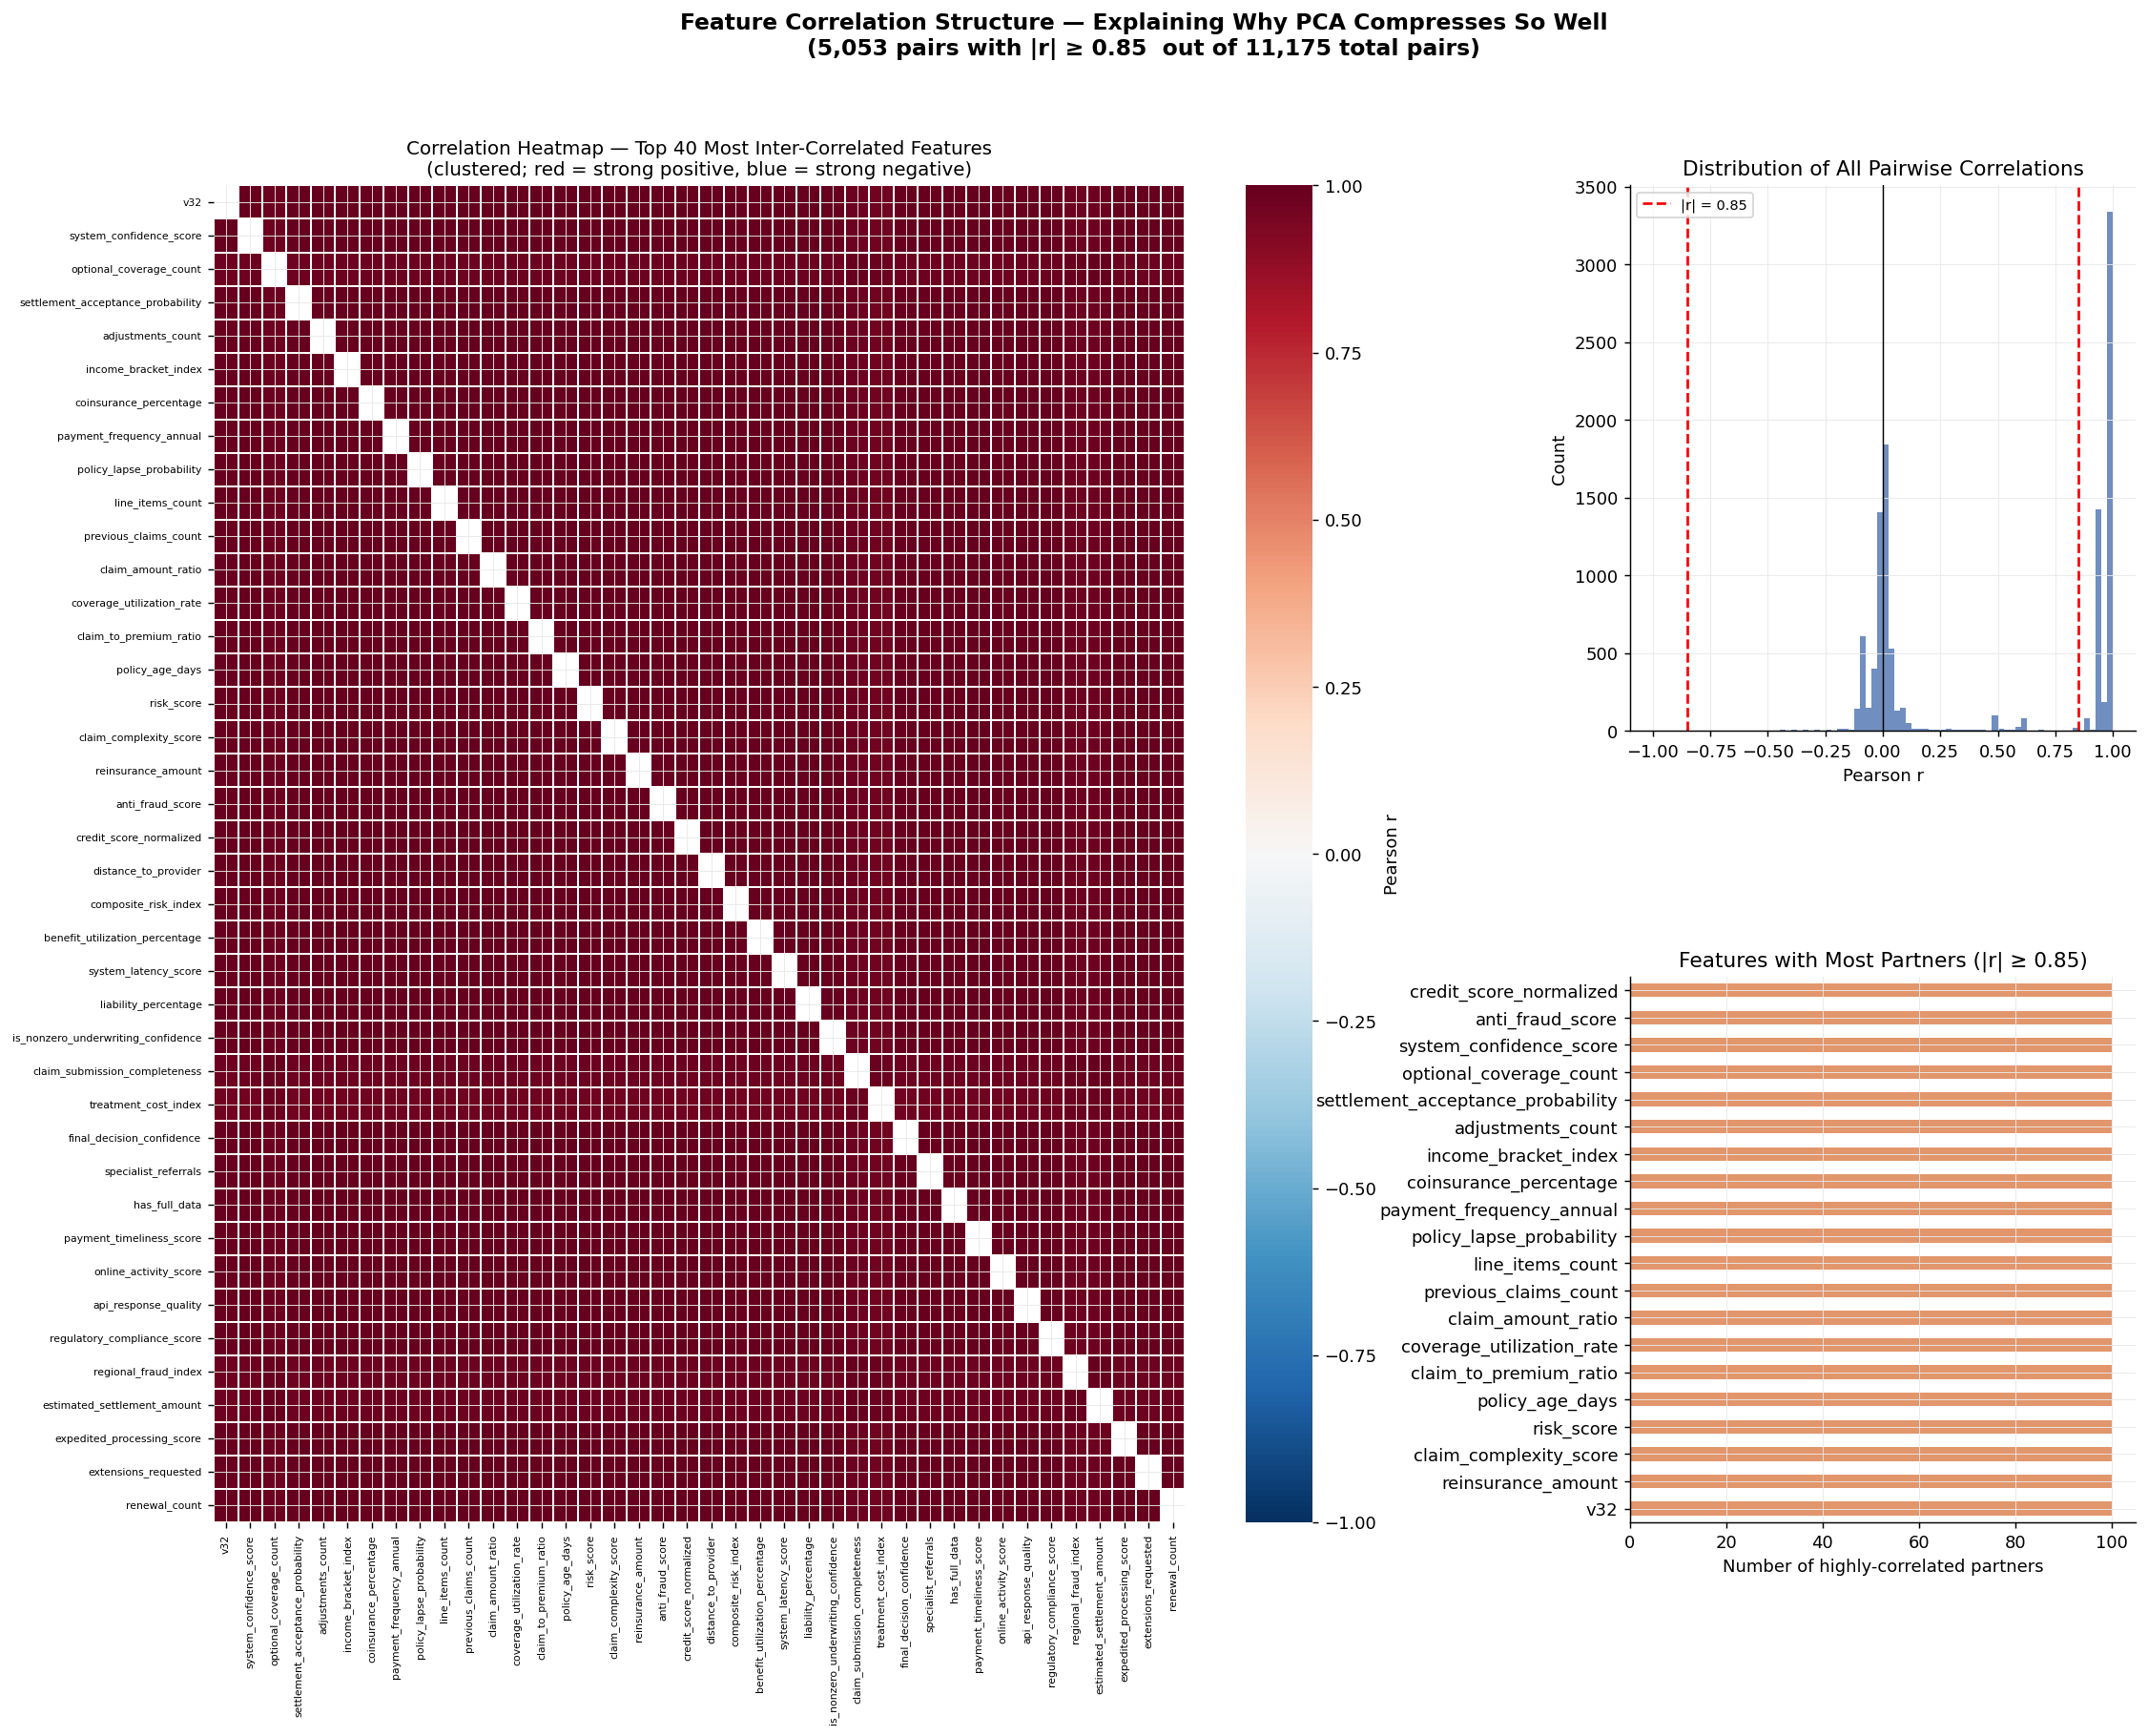


════════════════════════════════════════════════════════════
  Feature Correlation Summary
════════════════════════════════════════════════════════════
  Total features           : 150
  Total pairs              : 11,175
  Pairs with |r| ≥ 0.85  : 5,053

  Top 15 most correlated pairs:
                     feature_A                         feature_B  pearson_r
                           v32            claim_to_premium_ratio        1.0
         previous_claims_count           system_confidence_score        1.0
            total_claim_amount            coinsurance_percentage        1.0
claim_received_to_review_hours         documents_submitted_count        1.0
            total_claim_amount settlement_acceptance_probability        1.0
         previous_claims_count           endorsement_value_ratio        1.0
claim_received_to_review_hours       customer_satisfaction_score        1.0
         previous_claims_count          payment_frequency_annual        1.0
            total_claim_amou

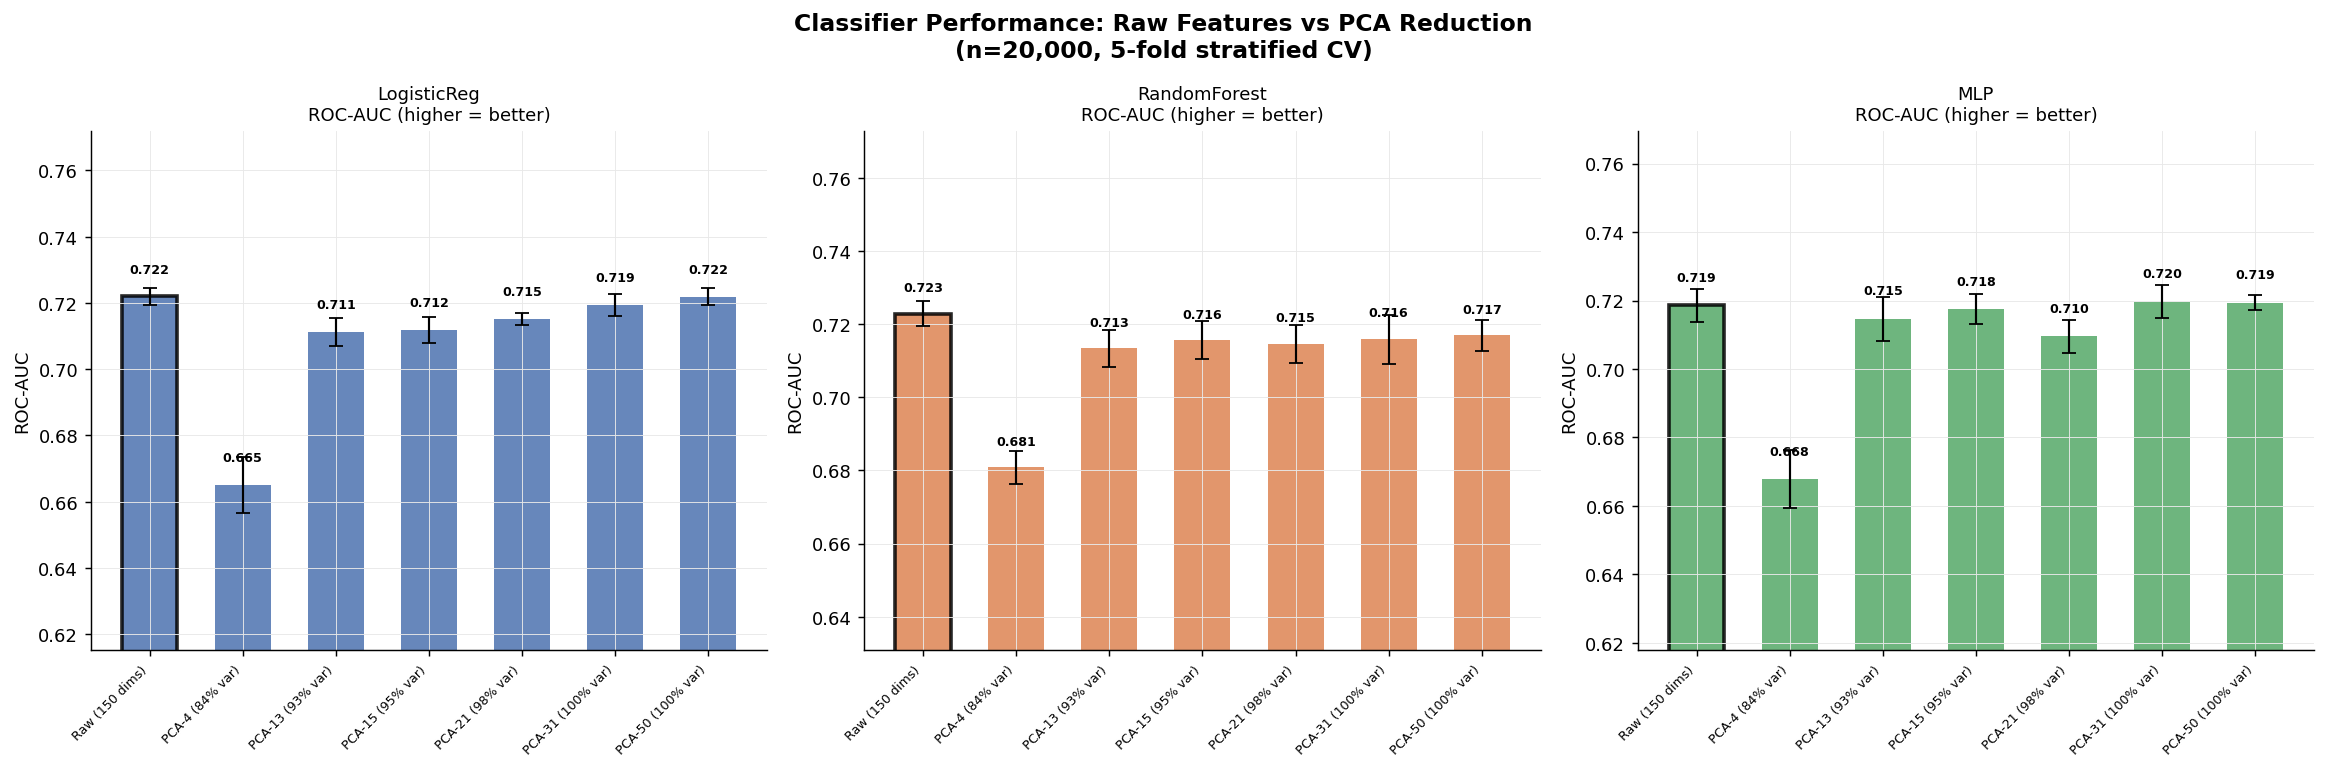


════════════════════════════════════════════════════════════════════════════════
  Classification Results Summary
════════════════════════════════════════════════════════════════════════════════
classifier         LogisticReg     MLP  RandomForest
configuration                                       
Raw (150 dims)          0.7220  0.7186        0.7229
PCA-4 (84% var)         0.6651  0.6678        0.6808
PCA-13 (93% var)        0.7112  0.7146        0.7134
PCA-15 (95% var)        0.7118  0.7175        0.7156
PCA-21 (98% var)        0.7151  0.7095        0.7147
PCA-31 (100% var)       0.7193  0.7196        0.7159
PCA-50 (100% var)       0.7219  0.7193        0.7169

  Best configuration per classifier (by ROC-AUC):
    LogisticReg    : Raw (150 dims)                  AUC=0.7220  (Δ vs raw: +0.0000)
    RandomForest   : Raw (150 dims)                  AUC=0.7229  (Δ vs raw: +0.0000)
    MLP            : PCA-31 (100% var)               AUC=0.7196  (Δ vs raw: +0.0010)
═════════════════════

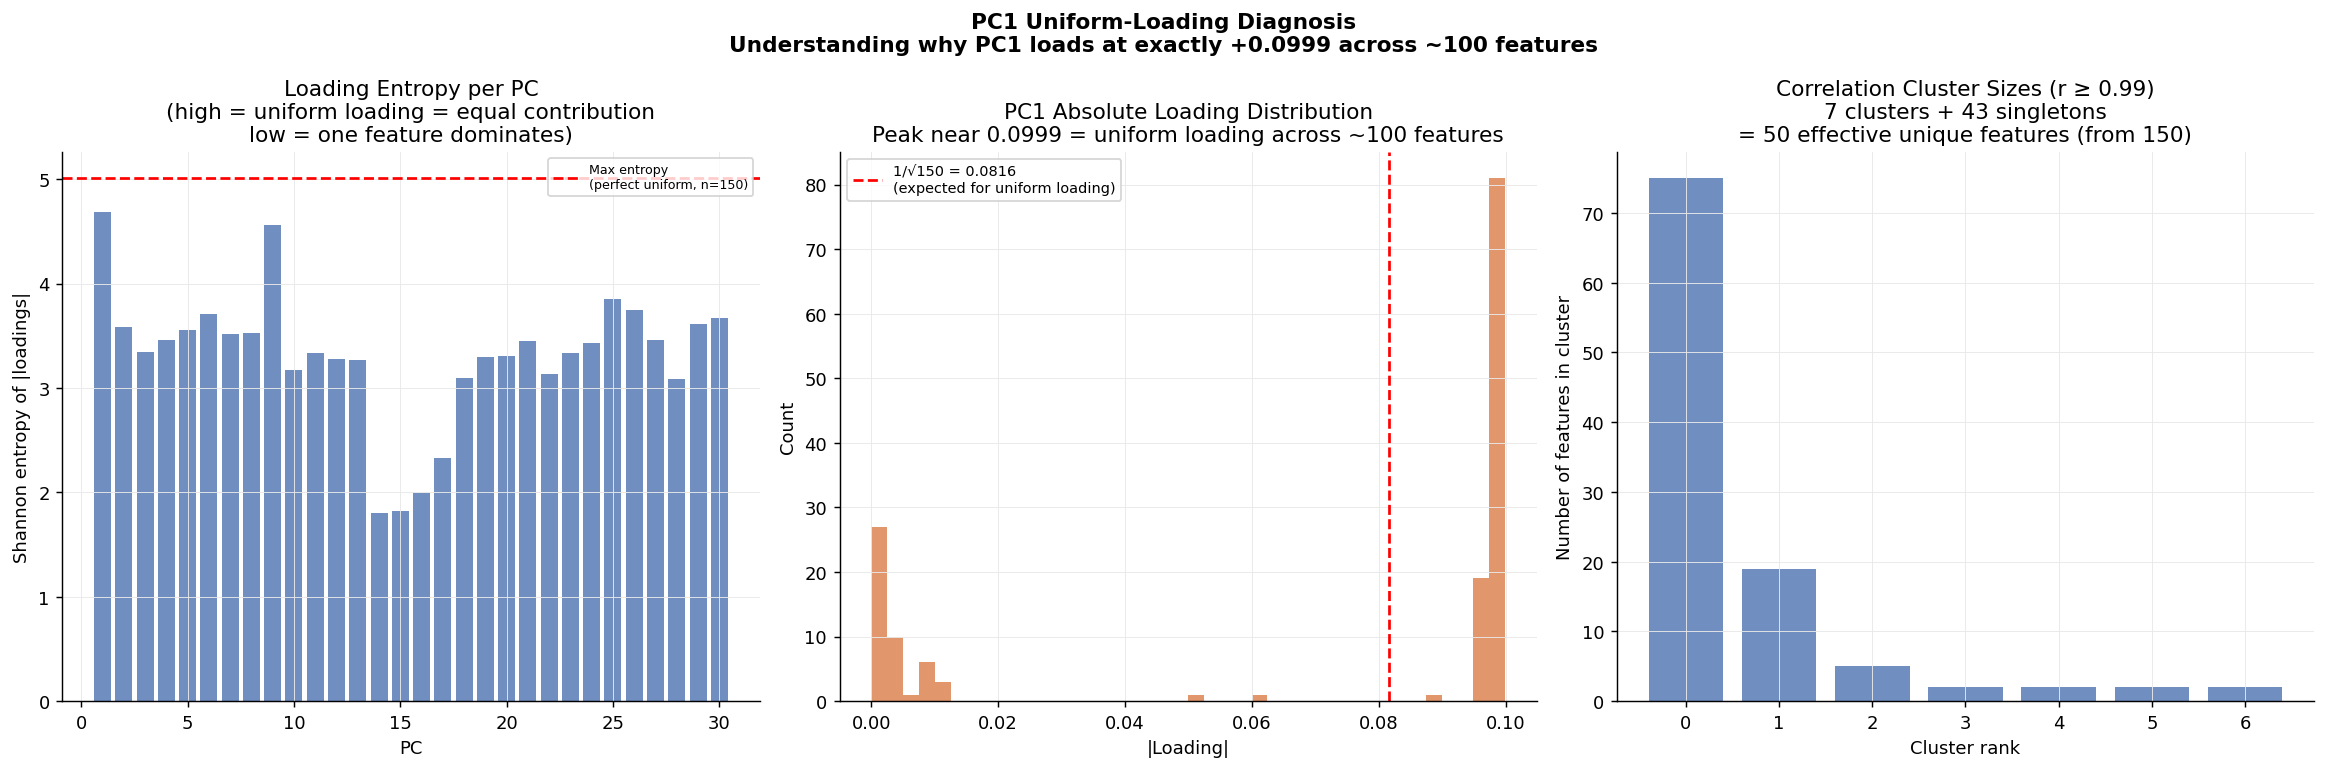


═════════════════════════════════════════════════════════════════
  PC1 Uniform-Loading Diagnosis
═════════════════════════════════════════════════════════════════
  Original features     : 150
  Correlation clusters  : 7  (groups with r ≥ 0.99)
  Singleton features    : 43
  Effective unique dims : 50  (true information content)

  PC1 entropy           : 4.6895
  Max possible entropy  : 5.0106  (uniform)
  Ratio                 : 0.936

  → PC1 entropy ratio near 1.0 confirms it is loading
    nearly uniformly across all features.
    This happens because 107 features are
    strongly inter-correlated and share a common direction.

  Top 5 largest correlation clusters (r ≥ 0.99):
    [75 members]: claim_amount_ratio, risk_score, deductible_ratio, claim_reserve_amount, policy_value_score...
    [19 members]: premium_payment_score, days_since_policy_start, medical_necessity_score, loss_ratio_history, claim_validity_score...
    [5 members]: estimated_settlement_amount, policy_complian

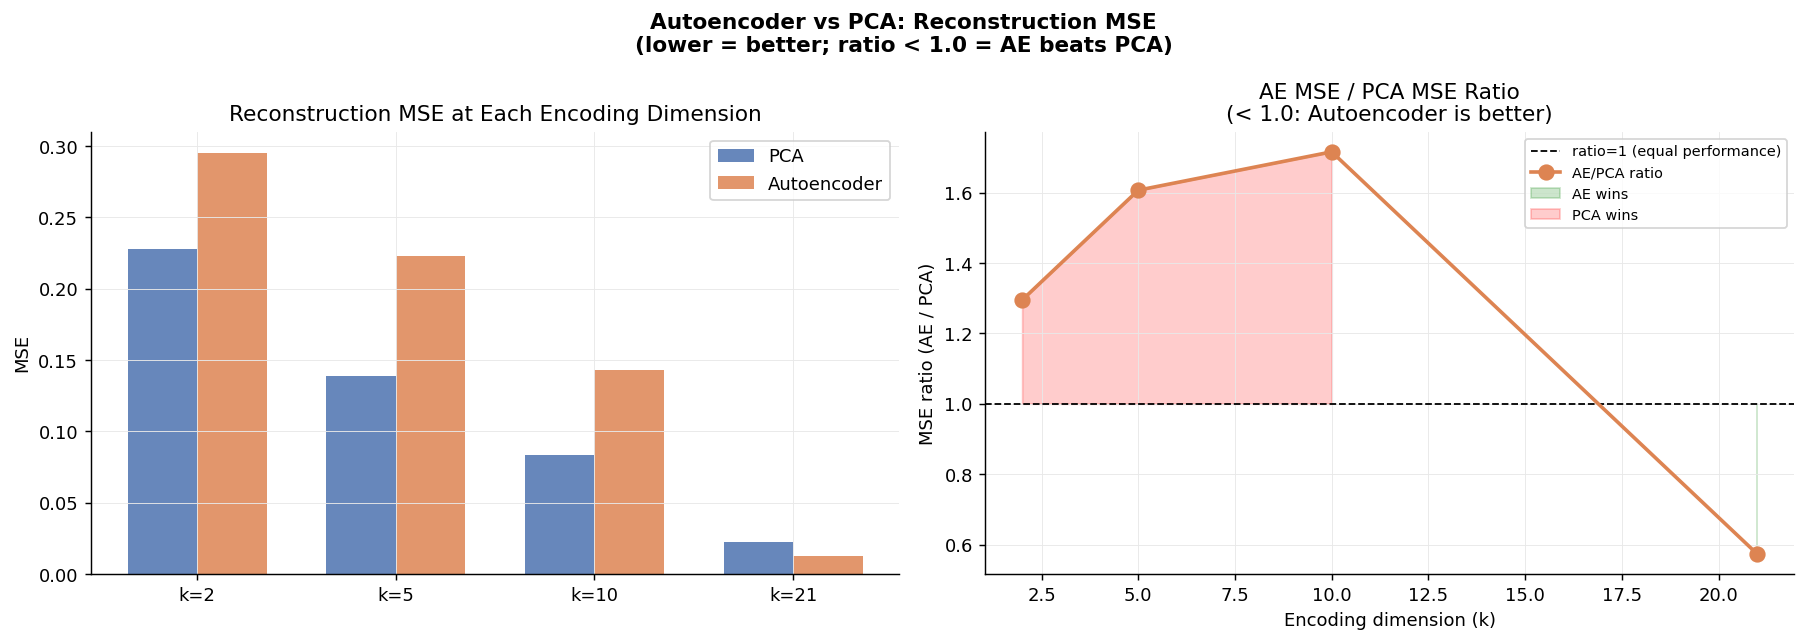


  PCA wins at 3/4 encoding dimensions
  AE  wins at 1/4 encoding dimensions
  → PCA is recommended: linear reduction is sufficient.
    The data does not have strong non-linear structure
    that an autoencoder can exploit over PCA.

═════════════════════════════════════════════════════════════════
  ✅  All extra analyses saved to: ./outputs/dr_extra
═════════════════════════════════════════════════════════════════


In [53]:
results = run_all_extras(
    X          = X_train,   # your feature DataFrame
    y          = y_train_numeric,   # target Series
    save_path  = "./outputs/dr_extra",
)